# Preprocess

In [22]:
from pipeline_preprocess import run_full_pipeline
resultats = run_full_pipeline(r"C:\TSQ\data\data1.csv")

df = resultats["df"]
df_PS = resultats["df_PS"]
df_PD = resultats["df_PD"]

df_SD = resultats["df_SD"]
df_SD_PS = resultats["df_SD_PS"]
df_SD_PD = resultats["df_SD_PD"]

df_BAI = resultats["df_BAI"]
df_TSQ = resultats["df_TSQ"]
df_TSQ_PD = resultats["df_TSQ_PD"]

df_EP = resultats["df_EP"]
df_EP_PD = resultats["df_EP_PD"]

df_16 = resultats["df_16"]
df_16_PD = resultats["df_16_PD"]
echelle1 = resultats["echelle1"]
echelle2 = resultats["echelle2"]

df_sub = resultats["df_sub"]

df_ZTPI = resultats["df_ZTPI"]
df_ZTPI_PD = resultats["df_ZTPI_PD"]


Nombre de lignes complètement vides : 0


# Création de groupes au sein de l'échelle TSQ: 0 = sain,  1 = personne avec diag

In [23]:
# Copie "brute" gardée AVANT le renommage TSQ1..40 
df_TSQ_PD_raw = resultats["df_TSQ_PD"].copy()

In [24]:
import pandas as pd
df_TSQ = df_TSQ.copy()
df_TSQ["group"] = 0

df_TSQ_PD = df_TSQ_PD.copy()
df_TSQ_PD["group"] = 1

df_all = pd.concat([df_TSQ, df_TSQ_PD])
group = df_all["group"]          
df_all = df_all.drop(columns="group")   


In [3]:
dfs = [df_TSQ, df_TSQ_PD, df_all]

for df in dfs:
    
    cols_tsq_brutes = df.columns[0:40]

    # On renomme les 40 items : TSQ1 → TSQ40
    new_names = [f"TSQ{i}" for i in range(1, 41)]
    df.rename(columns=dict(zip(cols_tsq_brutes, new_names)), inplace=True)

    df[new_names] = df[new_names].apply(
        lambda col: col.astype(str).str.extract(r"(\d+)")[0].astype(float)
    )


# Correlation des 40x40 items + greedy glouton

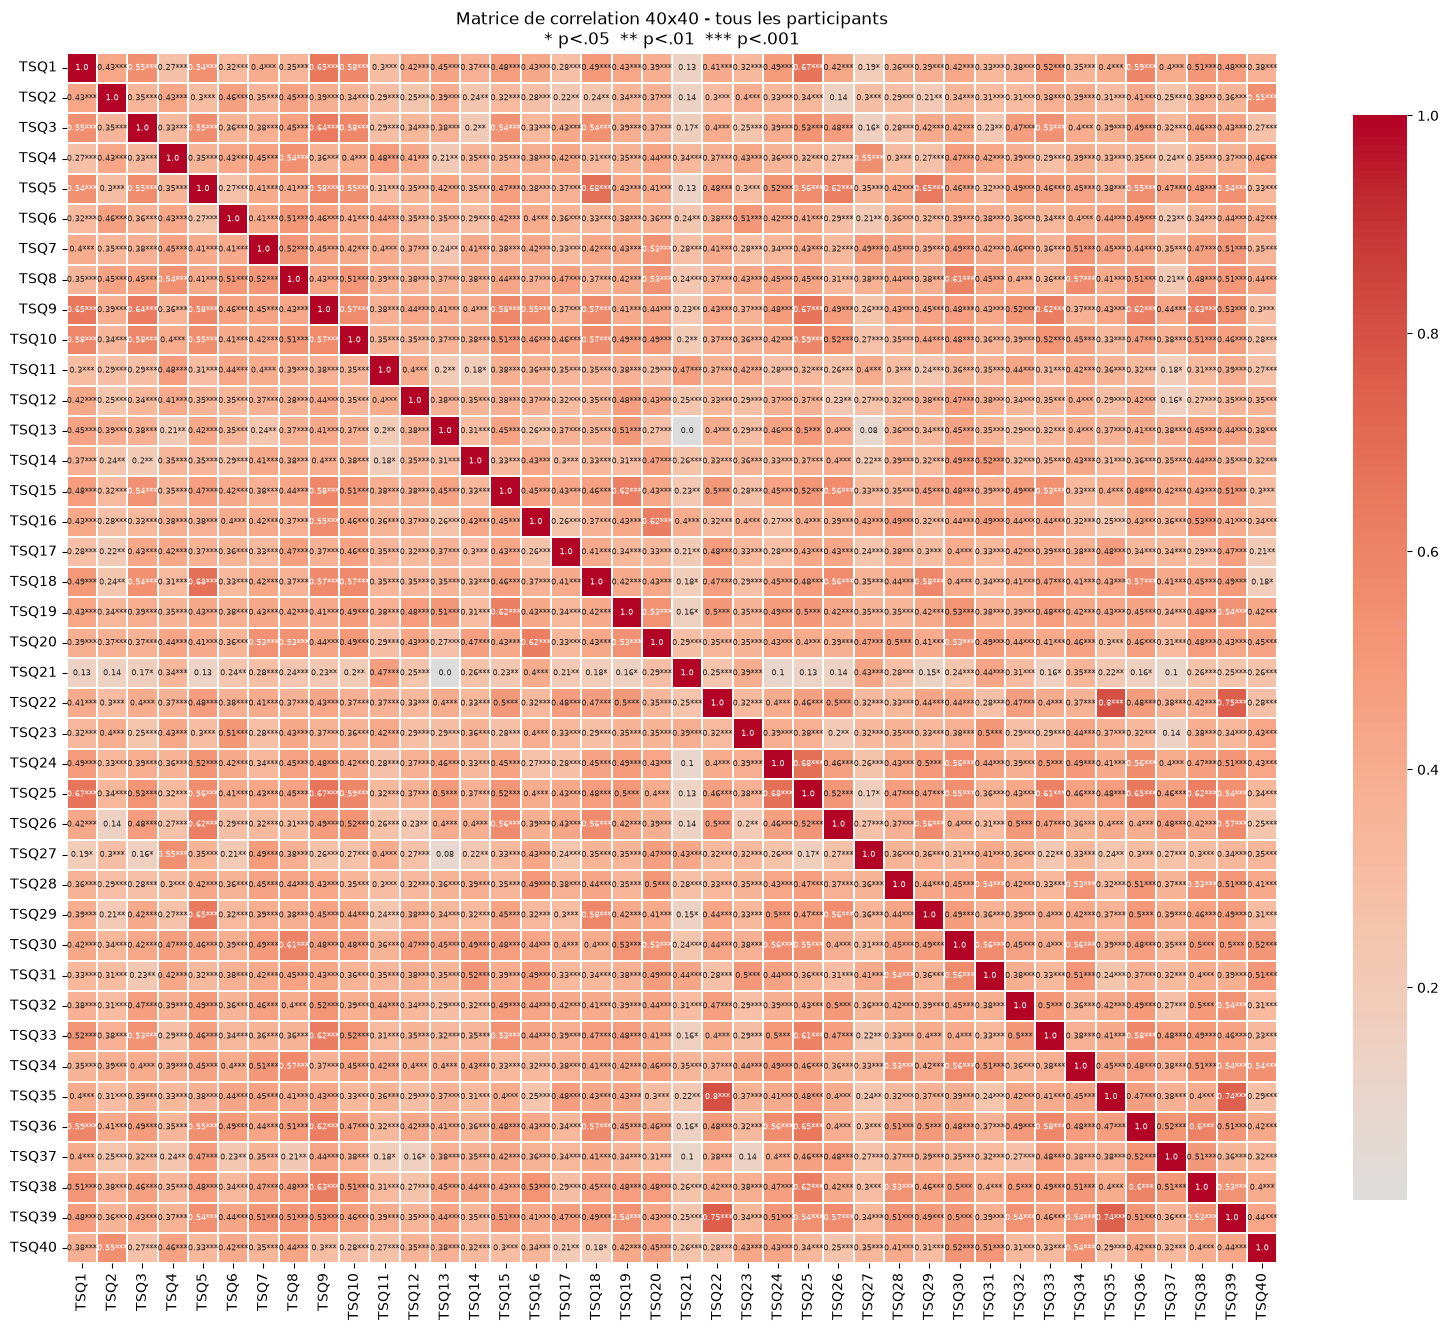

Items conservés : ['TSQ1', 'TSQ2', 'TSQ3', 'TSQ4', 'TSQ6', 'TSQ7', 'TSQ8', 'TSQ10', 'TSQ11', 'TSQ12', 'TSQ13', 'TSQ14', 'TSQ15', 'TSQ16', 'TSQ17', 'TSQ18', 'TSQ19', 'TSQ20', 'TSQ21', 'TSQ23', 'TSQ24', 'TSQ26', 'TSQ27', 'TSQ28', 'TSQ29', 'TSQ30', 'TSQ31', 'TSQ32', 'TSQ33', 'TSQ34', 'TSQ35', 'TSQ36', 'TSQ37', 'TSQ38', 'TSQ40']
Items retirés : ['TSQ5', 'TSQ9', 'TSQ22', 'TSQ25', 'TSQ39']


In [4]:
from correl_TSQ import compute_tsq_corr

compute_tsq_corr(df_all, items=[f"TSQ{i}" for i in range(1, 41)], title="Matrice de correlation 40x40 - tous les participants")

from correl_TSQ import reduce_correlated_features
items = [f"TSQ{i}" for i in range(1, 41)]
selected_items = reduce_correlated_features(df_all, items, threshold=0.65)

print("Items conservés :", selected_items)
print("Items retirés :", [i for i in items if i not in selected_items])



In [5]:
colonnes_a_exclure = ['TSQ1', 'TSQ5', 'TSQ9', 'TSQ22', 'TSQ25','TSQ36', 'TSQ39', 'score_total']  # remplace par tes colonnes
df_red_sains = df_TSQ.drop(columns=colonnes_a_exclure)
df_red_pd = df_TSQ_PD.drop(columns=colonnes_a_exclure)

# Split train/test des participants sains + UMAP sur train + Clustering sur train + Classifier (4 modeles) avec GridSearch 

c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


cluster
0    68
1    47
Name: count, dtype: int64
Cluster 0: 68 participants (group 0: 68)
Cluster 1: 47 participants (group 0: 47)

=== Répartition train (fit) ===
0    68
1    47
Name: count, dtype: int64

=== Répartition test (via predict, pas refit) ===
0    30
1     9
Name: count, dtype: int64

=== LogisticRegression ===


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Li

Meilleurs params : {'clf__C': 0.1, 'clf__penalty': 'l2'}
Meilleur score CV : 0.956
Score sur test set : 0.944


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Li

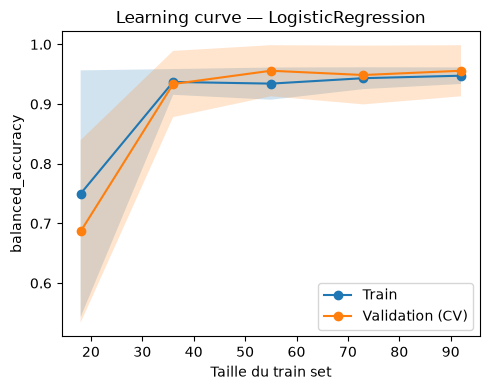


=== SVM_RBF ===


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1

Meilleurs params : {'clf__C': 0.1, 'clf__gamma': 'scale'}
Meilleur score CV : 0.959
Score sur test set : 0.944


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1

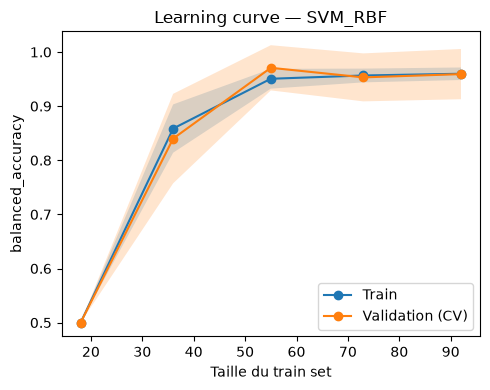


=== RandomForest ===
Meilleurs params : {'clf__max_depth': None, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 100}
Meilleur score CV : 0.94
Score sur test set : 0.889


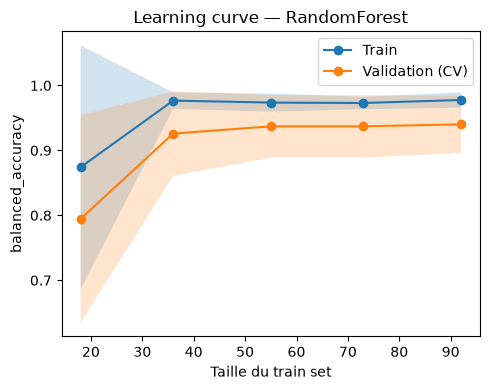


=== HistGradientBoosting ===
Meilleurs params : {'clf__learning_rate': 0.01, 'clf__max_depth': None, 'clf__max_iter': 400}
Meilleur score CV : 0.951
Score sur test set : 0.889


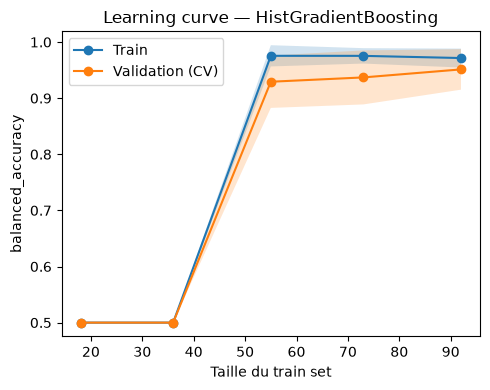


=== Comparaison des modèles ===
                      CV score  Test score
SVM_RBF               0.959219    0.944444
LogisticRegression    0.955800    0.944444
HistGradientBoosting  0.951282    0.888889
RandomForest          0.940171    0.888889

Meilleur modèle : SVM_RBF
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        30
           1       1.00      0.89      0.94         9

    accuracy                           0.97        39
   macro avg       0.98      0.94      0.96        39
weighted avg       0.98      0.97      0.97        39



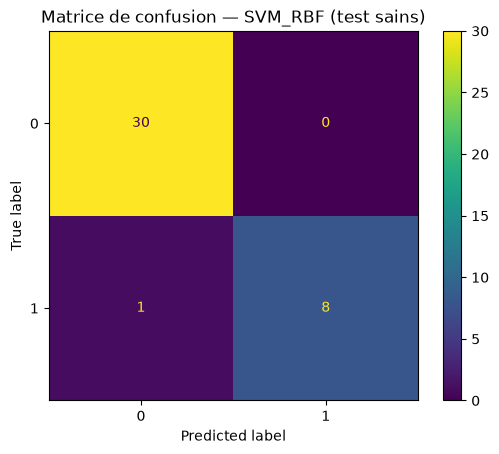

In [6]:
from testclust import split_umap_clustering_train_test
from pipeline_ML import train_and_compare_classifiers, apply_to_patients

split_result = split_umap_clustering_train_test(
    df_red_sains, n_clusters=2, test_size=0.25, random_state=42, group=group,
)

X_train, X_test = split_result["X_train_2d"], split_result["X_test_2d"]
y_train, y_test = split_result["y_train"], split_result["y_test"]

results, summary, best_model_name, best_model = train_and_compare_classifiers(
    X_train, y_train, X_test, y_test, scoring="balanced_accuracy"
)

# Réprésentation de la prédiction de la position des patients sur les clusterss 0 ou 1 dans l'espace UMAP des participants sains

In [7]:
df_patients_pred = apply_to_patients(
    best_model,
    split_result["res_train"].umap_2d_model,   
    df_red_pd,
)

print(df_patients_pred["predicted_cluster"].value_counts().sort_index())

predicted_cluster
0    15
1    16
Name: count, dtype: int64


In [9]:
import pandas as pd
import plotly.express as px

res_train = split_result["res_train"]

X_patients_umap = res_train.umap_2d_model.transform(df_red_pd.values)

hover_train = [f"Participant {i}" for i in split_result["df_train"].index]
hover_test  = [f"Participant {i}" for i in split_result["df_test"].index]
hover_diag  = [f"Participant {i}" for i in df_red_pd.index]

df_plot = pd.concat([
    pd.DataFrame({
        "x": split_result["X_train_2d"][:, 0], "y": split_result["X_train_2d"][:, 1],
        "cluster": split_result["y_train"].astype(str),
        "type": "Sains (train)",
        "participant": hover_train,
    }),
    pd.DataFrame({
        "x": split_result["X_test_2d"][:, 0], "y": split_result["X_test_2d"][:, 1],
        "cluster": split_result["y_test"].astype(str),
        "type": "Sains (test)",
        "participant": hover_test,
    }),
    pd.DataFrame({
        "x": X_patients_umap[:, 0], "y": X_patients_umap[:, 1],
        "cluster": df_patients_pred["predicted_cluster"].astype(str),
        "type": "Diag",
        "participant": hover_diag,
    }),
], ignore_index=True)

fig = px.scatter(
    df_plot, x="x", y="y",
    color="cluster", symbol="type",
    color_discrete_map={"0": "#A777F1", "1":'#FC6955'},
    symbol_map={"Sains (train)": "circle", "Sains (test)": "circle-open", "Diag": "triangle-up"},
    opacity=0.7,
    hover_name="participant",
    title="Sains (train/test) et patients projetés dans l'espace UMAP (fit sur train)",
)

for trace in fig.data:
    if "Diag" in trace.name:
        trace.marker.line = dict(width=1, color="black")

fig.show(renderer="browser")

# Suite 
 * Split train/test des participants sains + UMAP sur train + Clustering sur train 
* creation de chaque df pour chaque groupes d'items
* ajouter à la boucle : Classifier (4 modeles) avec GridSearch pour chaque df
* visualisation du best model sur le groupe de participants diag

In [10]:
#Core items

items_core_sz = ['TSQ2','TSQ4','TSQ7','TSQ8','TSQ10','TSQ11','TSQ12','TSQ15','TSQ19','TSQ20','TSQ21','TSQ24','TSQ30','TSQ31','TSQ34','TSQ40']
items_core_md = ['TSQ9','TSQ14','TSQ17','TSQ25','TSQ28','TSQ29','TSQ36']
items_core_ma = ['TSQ22','TSQ32','TSQ35','TSQ39']
items_core_an = ['TSQ1','TSQ5','TSQ6','TSQ9','TSQ13','TSQ16','TSQ17','TSQ20','TSQ23','TSQ33','TSQ35','TSQ37','TSQ38','TSQ39']
items_core_pt = ['TSQ2','TSQ3','TSQ5','TSQ6','TSQ17','TSQ18','TSQ26','TSQ30','TSQ37']

#Periphery items
items_per_sz = ['TSQ1','TSQ3','TSQ5','TSQ6','TSQ13','TSQ14','TSQ23','TSQ27','TSQ35','TSQ38','TSQ39']
items_per_md = ['TSQ1','TSQ2','TSQ8','TSQ12','TSQ16','TSQ18','TSQ19','TSQ20','TSQ23','TSQ27','TSQ31']
items_per_ma = ['TSQ3','TSQ7','TSQ9','TSQ19','TSQ21','TSQ30','TSQ34','TSQ37','TSQ38']
items_per_an = ['TSQ2','TSQ3','TSQ12','TSQ18','TSQ19','TSQ22','TSQ25','TSQ27','TSQ32']
items_per_pt = ['TSQ1','TSQ9','TSQ12','TSQ13','TSQ14','TSQ16','TSQ19','TSQ20','TSQ23','TSQ24','TSQ25','TSQ27','TSQ28','TSQ31','TSQ33','TSQ35','TSQ36','TSQ38','TSQ39','TSQ40']

#Combined Core+Periphery items 
items_tot_sz = items_core_sz + items_per_sz
items_tot_md = items_core_md + items_per_md
items_tot_ma = items_core_ma + items_per_ma
items_tot_an = items_core_an + items_per_an
items_tot_pt = items_core_pt + items_per_pt

In [11]:
# --- Core items ---
df_core_ax   = df_all[items_core_an].copy()
df_core_sz   = df_all[items_core_sz].copy()
df_core_mdd  = df_all[items_core_md].copy()
df_core_man  = df_all[items_core_ma].copy()
df_core_ptsd = df_all[items_core_pt].copy()

# --- Periphery items ---
df_periph_ax   = df_all[items_per_an].copy()
df_periph_sz   = df_all[items_per_sz].copy()
df_periph_mdd  = df_all[items_per_md].copy()
df_periph_man  = df_all[items_per_ma].copy()
df_periph_ptsd = df_all[items_per_pt].copy()

# --- Core + Periphery combinés ---
df_tot_ax   = df_all[items_tot_an].copy()
df_tot_sz   = df_all[items_tot_sz].copy()
df_tot_mdd  = df_all[items_tot_md].copy()
df_tot_man  = df_all[items_tot_ma].copy()
df_tot_ptsd = df_all[items_tot_pt].copy()

#dico
sous_echelles = {
    "core_ax": df_core_ax, "core_sz": df_core_sz, "core_mdd": df_core_mdd,
    "core_man": df_core_man, "core_ptsd": df_core_ptsd,
    "periph_ax": df_periph_ax, "periph_sz": df_periph_sz, "periph_mdd": df_periph_mdd,
    "periph_man": df_periph_man, "periph_ptsd": df_periph_ptsd,
}

In [12]:
# --- Core items ---
df_core_ax   = df_TSQ[items_core_an].copy()
df_core_sz   = df_TSQ[items_core_sz].copy()
df_core_mdd  = df_TSQ[items_core_md].copy()
df_core_man  = df_TSQ[items_core_ma].copy()
df_core_ptsd = df_TSQ[items_core_pt].copy()

# --- Periphery items ---
df_periph_ax   = df_TSQ[items_per_an].copy()
df_periph_sz   = df_TSQ[items_per_sz].copy()
df_periph_mdd  = df_TSQ[items_per_md].copy()
df_periph_man  = df_TSQ[items_per_ma].copy()
df_periph_ptsd = df_TSQ[items_per_pt].copy()

# --- Core + Periphery combinés ---
df_tot_ax   = df_TSQ[items_tot_an].copy()
df_tot_sz   = df_TSQ[items_tot_sz].copy()
df_tot_mdd  = df_TSQ[items_tot_md].copy()
df_tot_man  = df_TSQ[items_tot_ma].copy()
df_tot_ptsd = df_TSQ[items_tot_pt].copy()

#dico
sous_echelles = {
    "core_ax": df_core_ax, "core_sz": df_core_sz, "core_mdd": df_core_mdd,
    "core_man": df_core_man, "core_ptsd": df_core_ptsd,
    "periph_ax": df_periph_ax, "periph_sz": df_periph_sz, "periph_mdd": df_periph_mdd,
    "periph_man": df_periph_man, "periph_ptsd": df_periph_ptsd,
}
# --- Core items ---
df_core_ax_PD   = df_TSQ_PD[items_core_an].copy()
df_core_sz_PD   = df_TSQ_PD[items_core_sz].copy()
df_core_mdd_PD  = df_TSQ_PD[items_core_md].copy()
df_core_man_PD  = df_TSQ_PD[items_core_ma].copy()
df_core_ptsd_PD = df_TSQ_PD[items_core_pt].copy()

# --- Periphery items ---
df_periph_ax_PD   = df_TSQ_PD[items_per_an].copy()
df_periph_sz_PD   = df_TSQ_PD[items_per_sz].copy()
df_periph_mdd_PD  = df_TSQ_PD[items_per_md].copy()
df_periph_man_PD  = df_TSQ_PD[items_per_ma].copy()
df_periph_ptsd_PD = df_TSQ_PD[items_per_pt].copy()

# --- Core + Periphery combinés ---
df_tot_ax_PD   = df_TSQ_PD[items_tot_an].copy()
df_tot_sz_PD   = df_TSQ_PD[items_tot_sz].copy()
df_tot_mdd_PD  = df_TSQ_PD[items_tot_md].copy()
df_tot_man_PD  = df_TSQ_PD[items_tot_ma].copy()
df_tot_ptsd_PD = df_TSQ_PD[items_tot_pt].copy()

#dico
sous_echelles_PD = {
    "core_ax_PD": df_core_ax_PD, "core_sz_PD": df_core_sz_PD, "core_mdd_PD": df_core_mdd_PD,
    "core_man_PD": df_core_man_PD, "core_ptsd_PD": df_core_ptsd_PD,
    "periph_ax_PD": df_periph_ax_PD, "periph_sz_PD": df_periph_sz_PD, "periph_mdd_PD": df_periph_mdd_PD,
    "periph_man_PD": df_periph_man_PD, "periph_ptsd_PD": df_periph_ptsd_PD,
}


========================= core_ax =========================


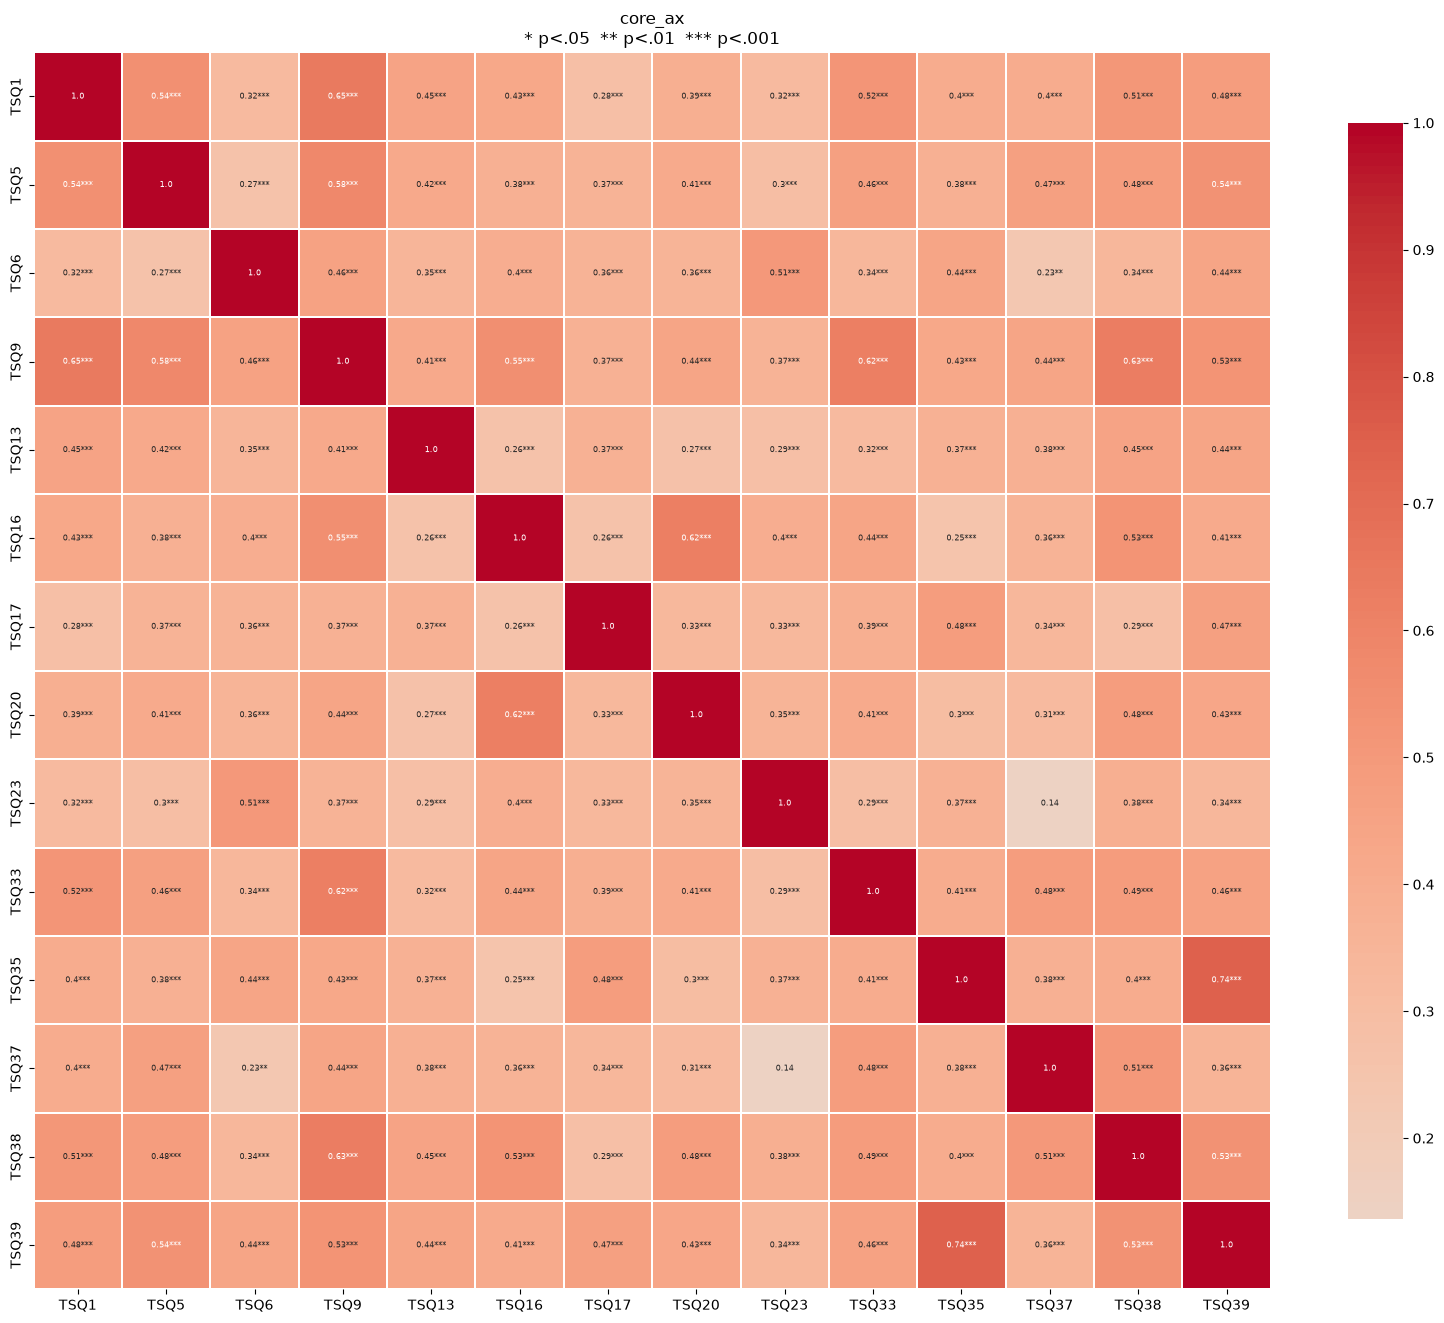

Items conservés (12/14) : ['TSQ1', 'TSQ5', 'TSQ6', 'TSQ13', 'TSQ16', 'TSQ17', 'TSQ20', 'TSQ23', 'TSQ33', 'TSQ35', 'TSQ37', 'TSQ38']
Items retirés (2) : ['TSQ9', 'TSQ39']

========================= core_sz =========================


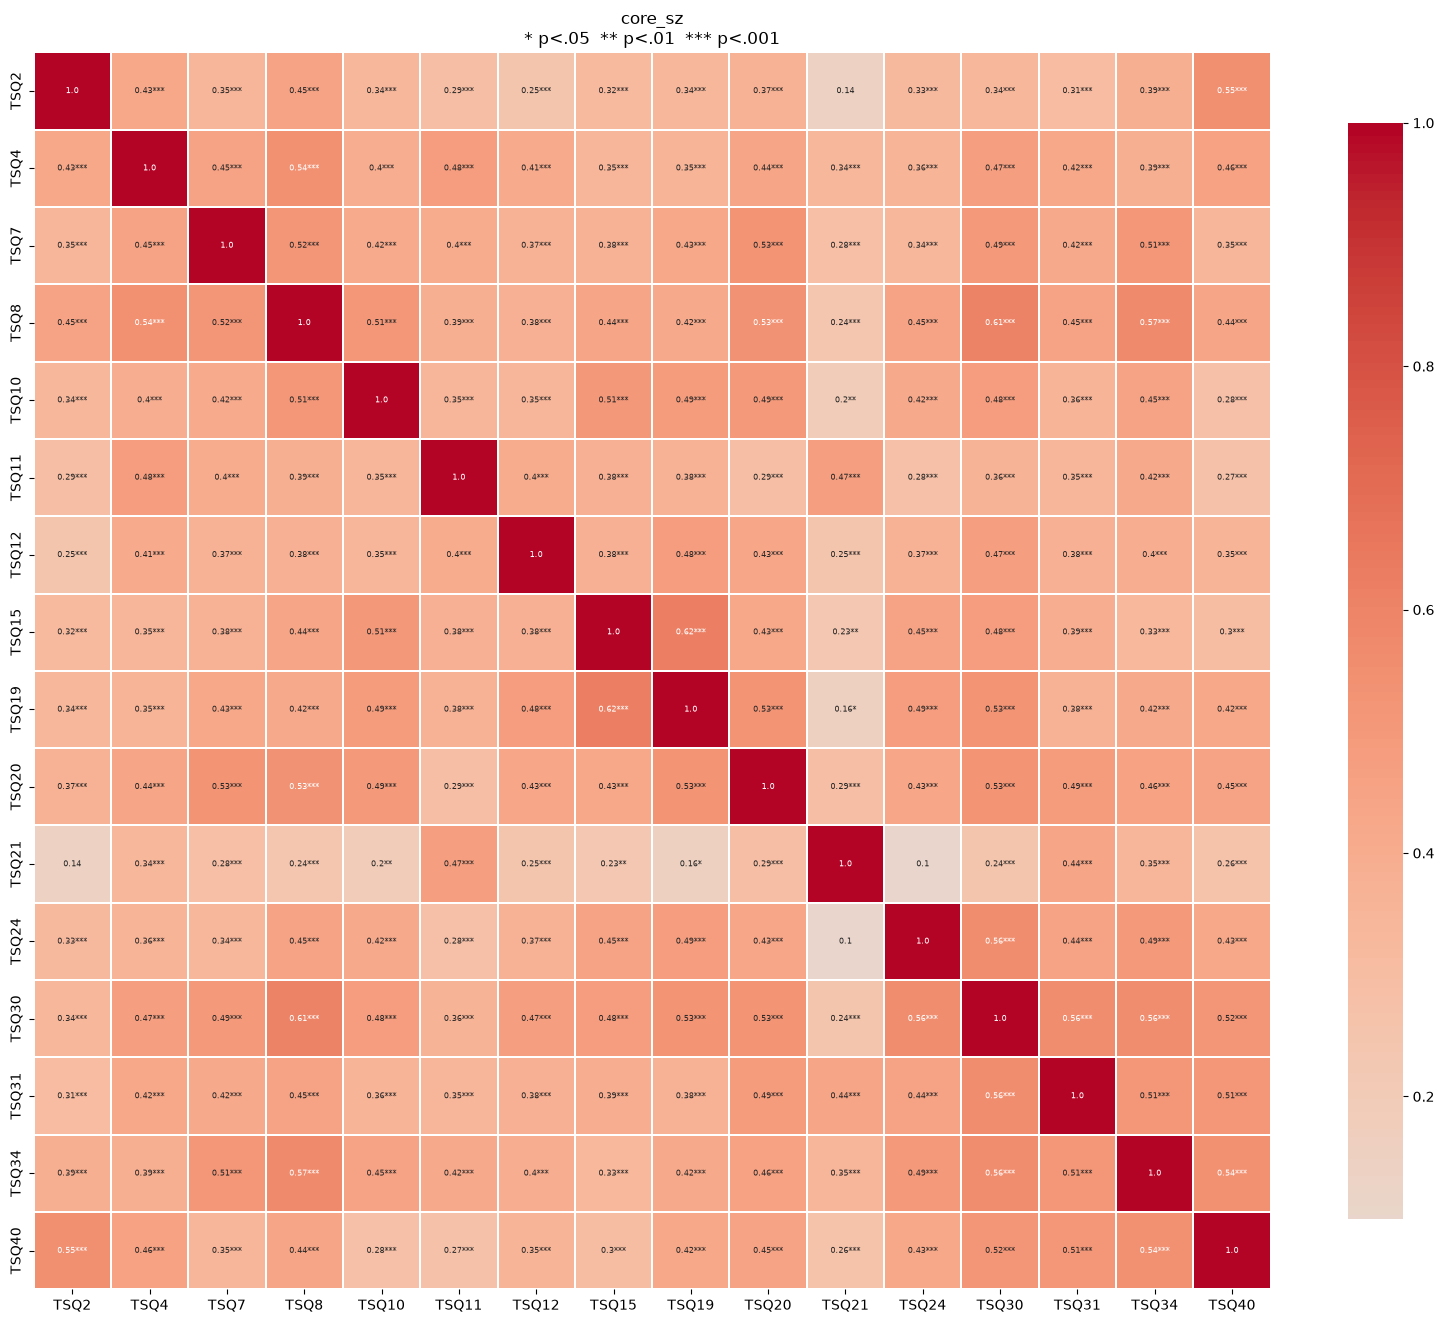

Items conservés (16/16) : ['TSQ2', 'TSQ4', 'TSQ7', 'TSQ8', 'TSQ10', 'TSQ11', 'TSQ12', 'TSQ15', 'TSQ19', 'TSQ20', 'TSQ21', 'TSQ24', 'TSQ30', 'TSQ31', 'TSQ34', 'TSQ40']
Items retirés (0) : []

========================= core_mdd =========================


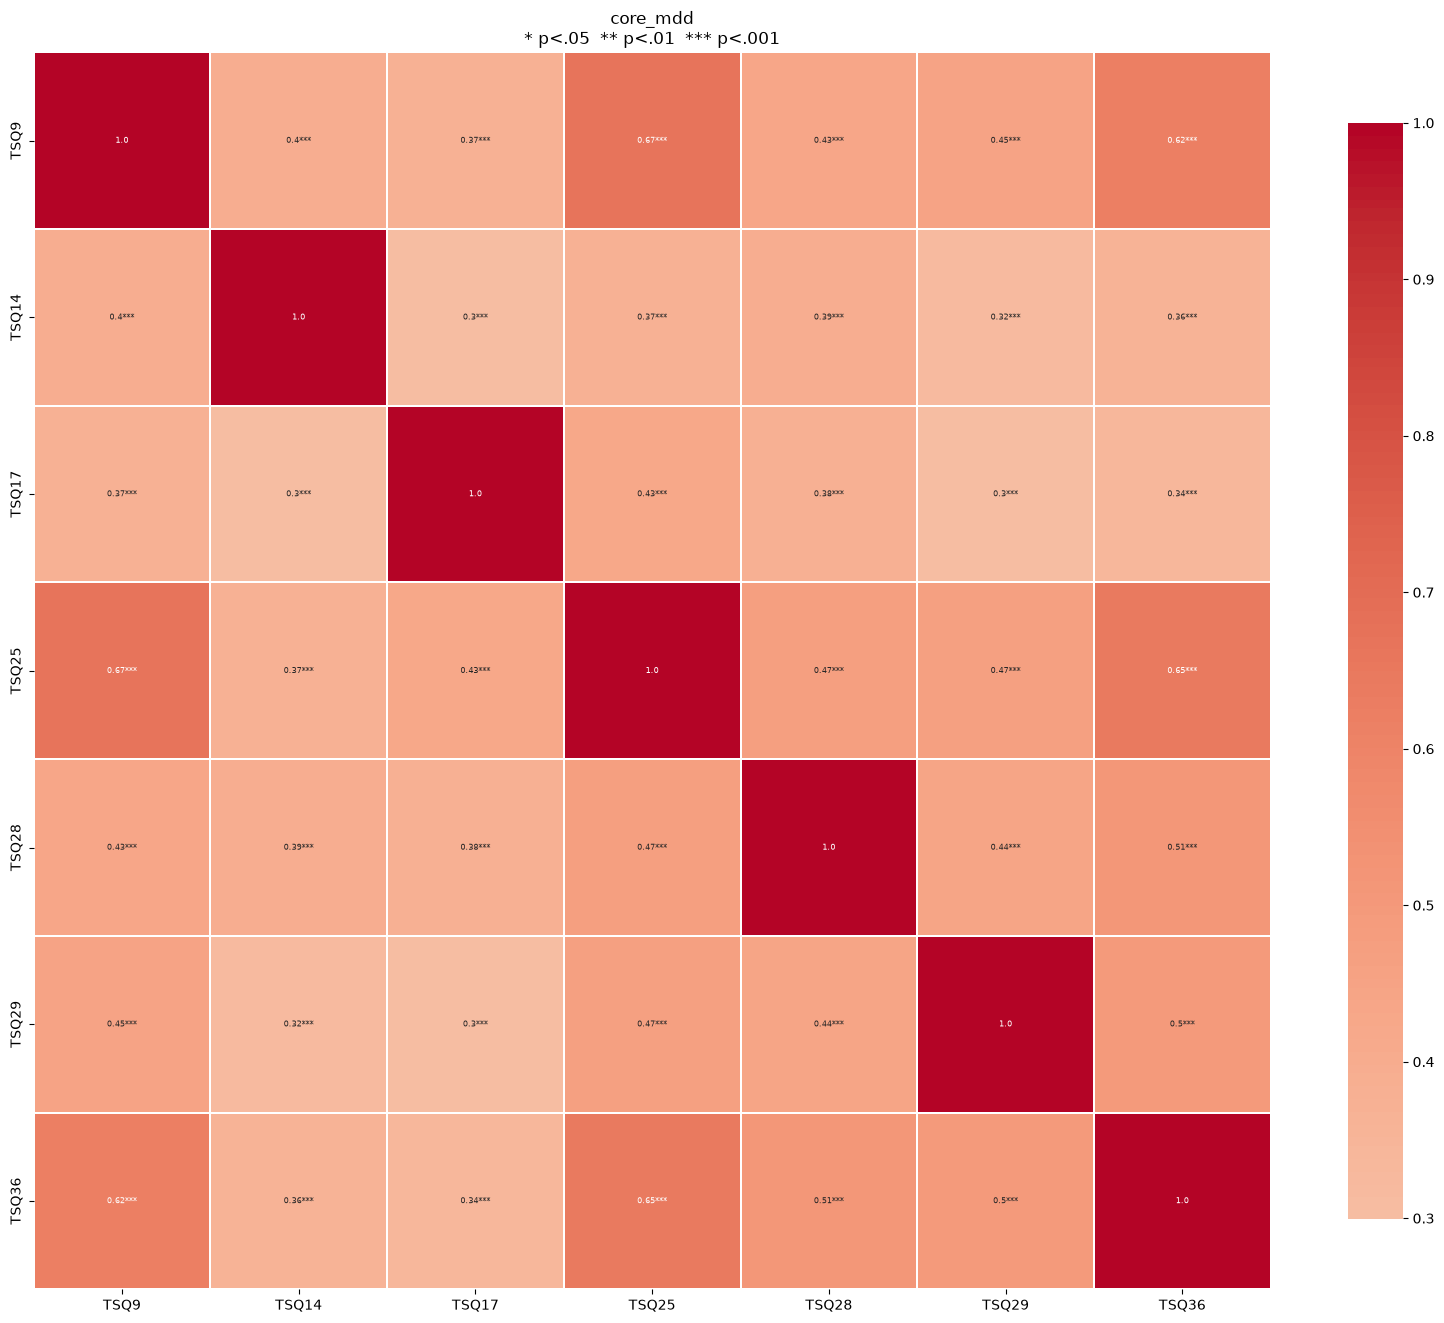

Items conservés (6/7) : ['TSQ9', 'TSQ14', 'TSQ17', 'TSQ28', 'TSQ29', 'TSQ36']
Items retirés (1) : ['TSQ25']

========================= core_man =========================


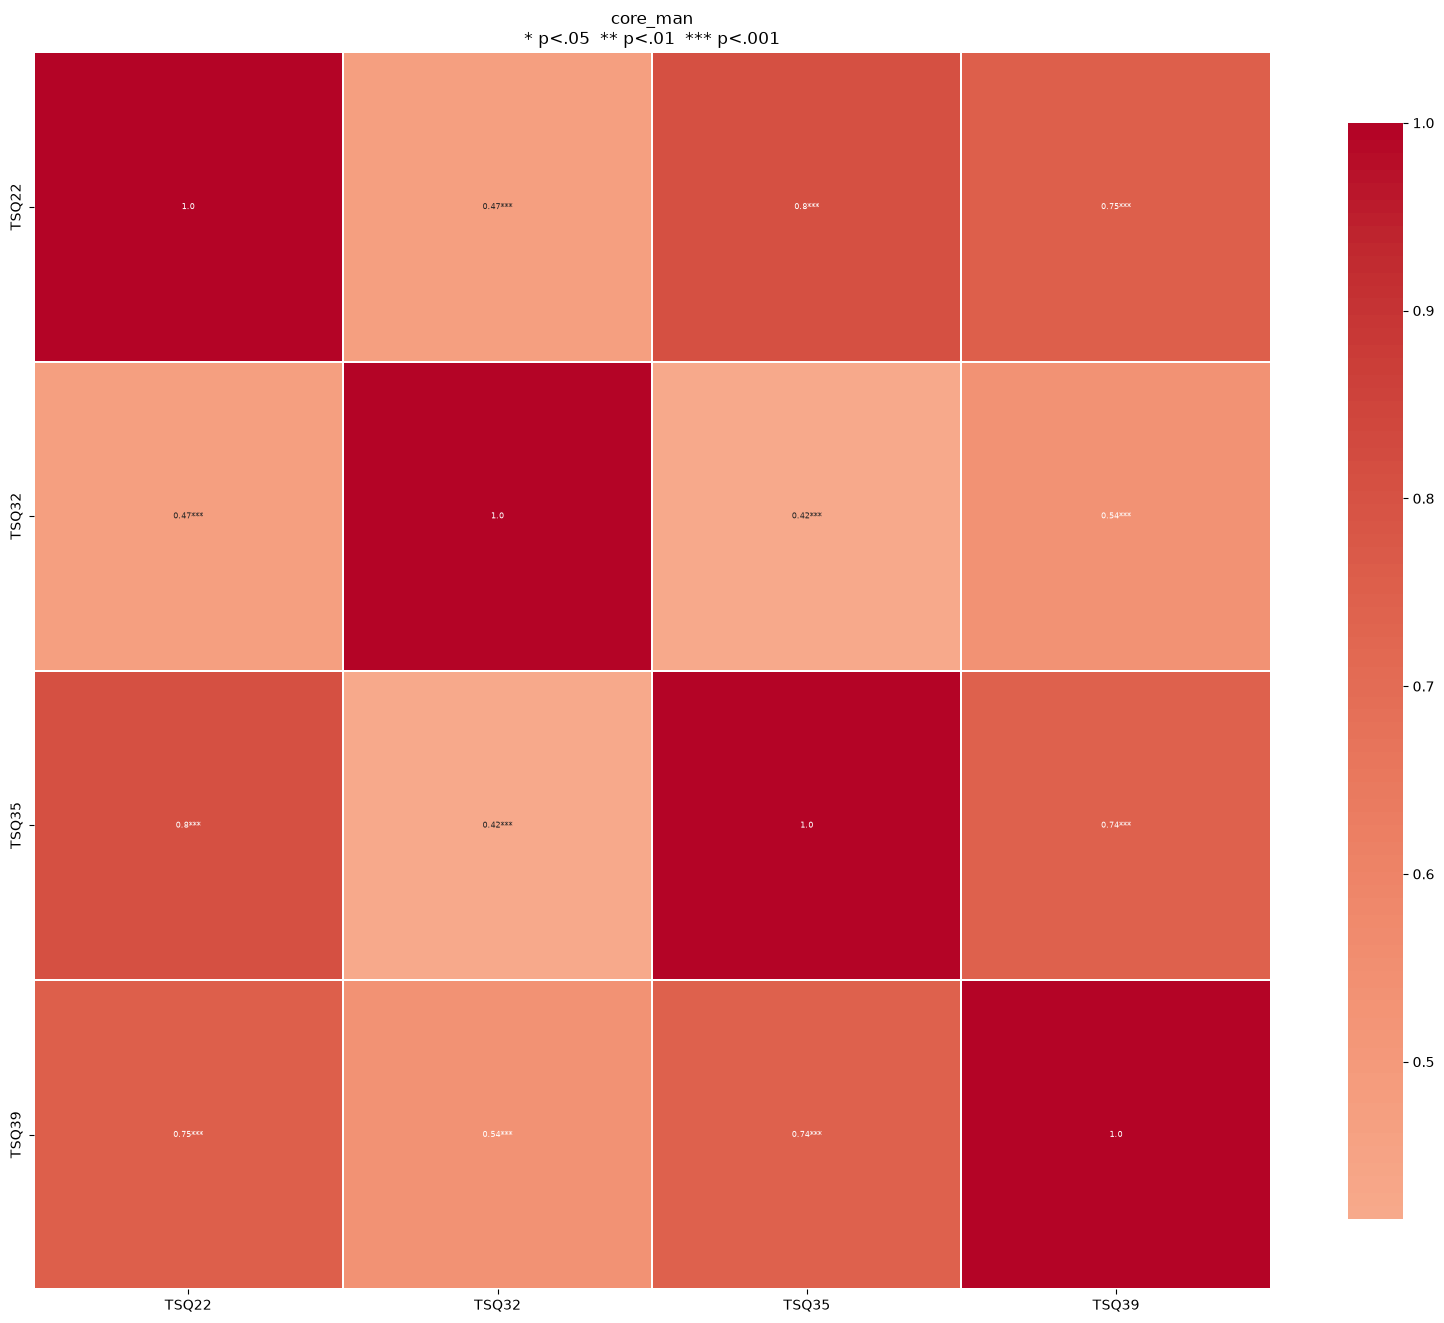

Items conservés (2/4) : ['TSQ32', 'TSQ35']
Items retirés (2) : ['TSQ22', 'TSQ39']

========================= core_ptsd =========================


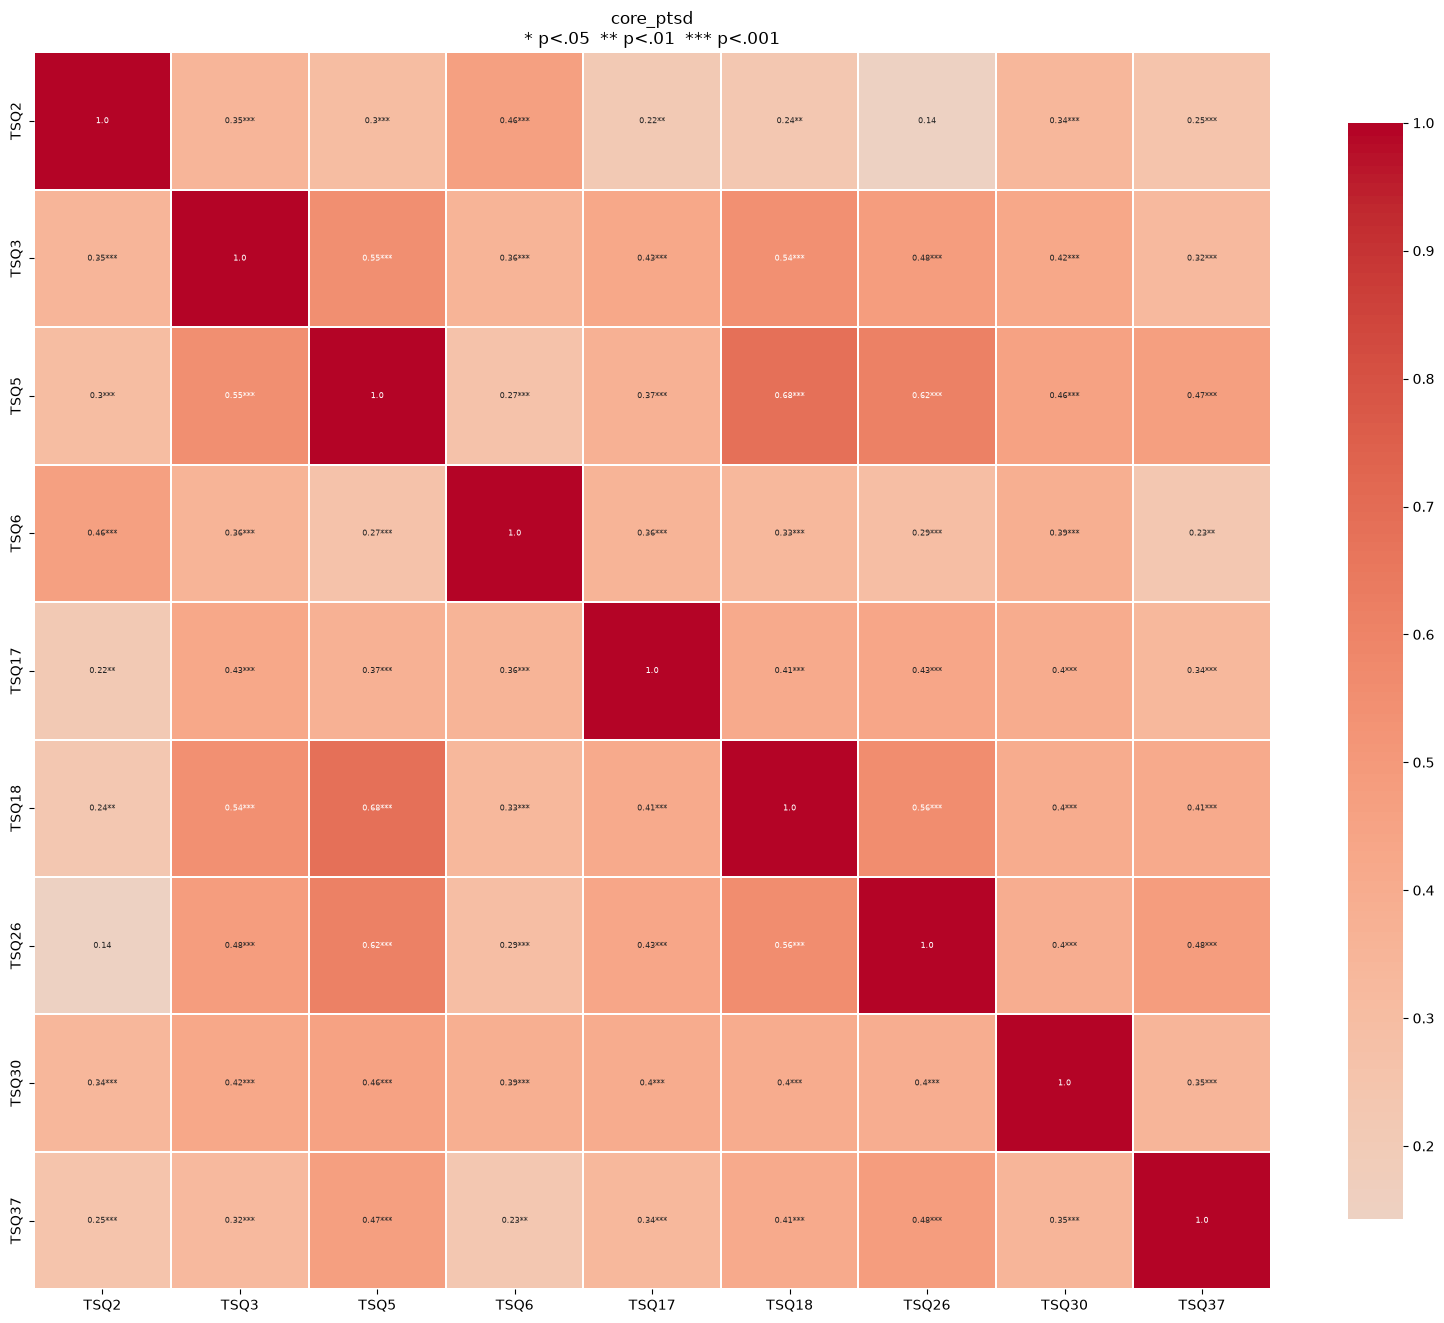

Items conservés (8/9) : ['TSQ2', 'TSQ3', 'TSQ6', 'TSQ17', 'TSQ18', 'TSQ26', 'TSQ30', 'TSQ37']
Items retirés (1) : ['TSQ5']

========================= periph_ax =========================


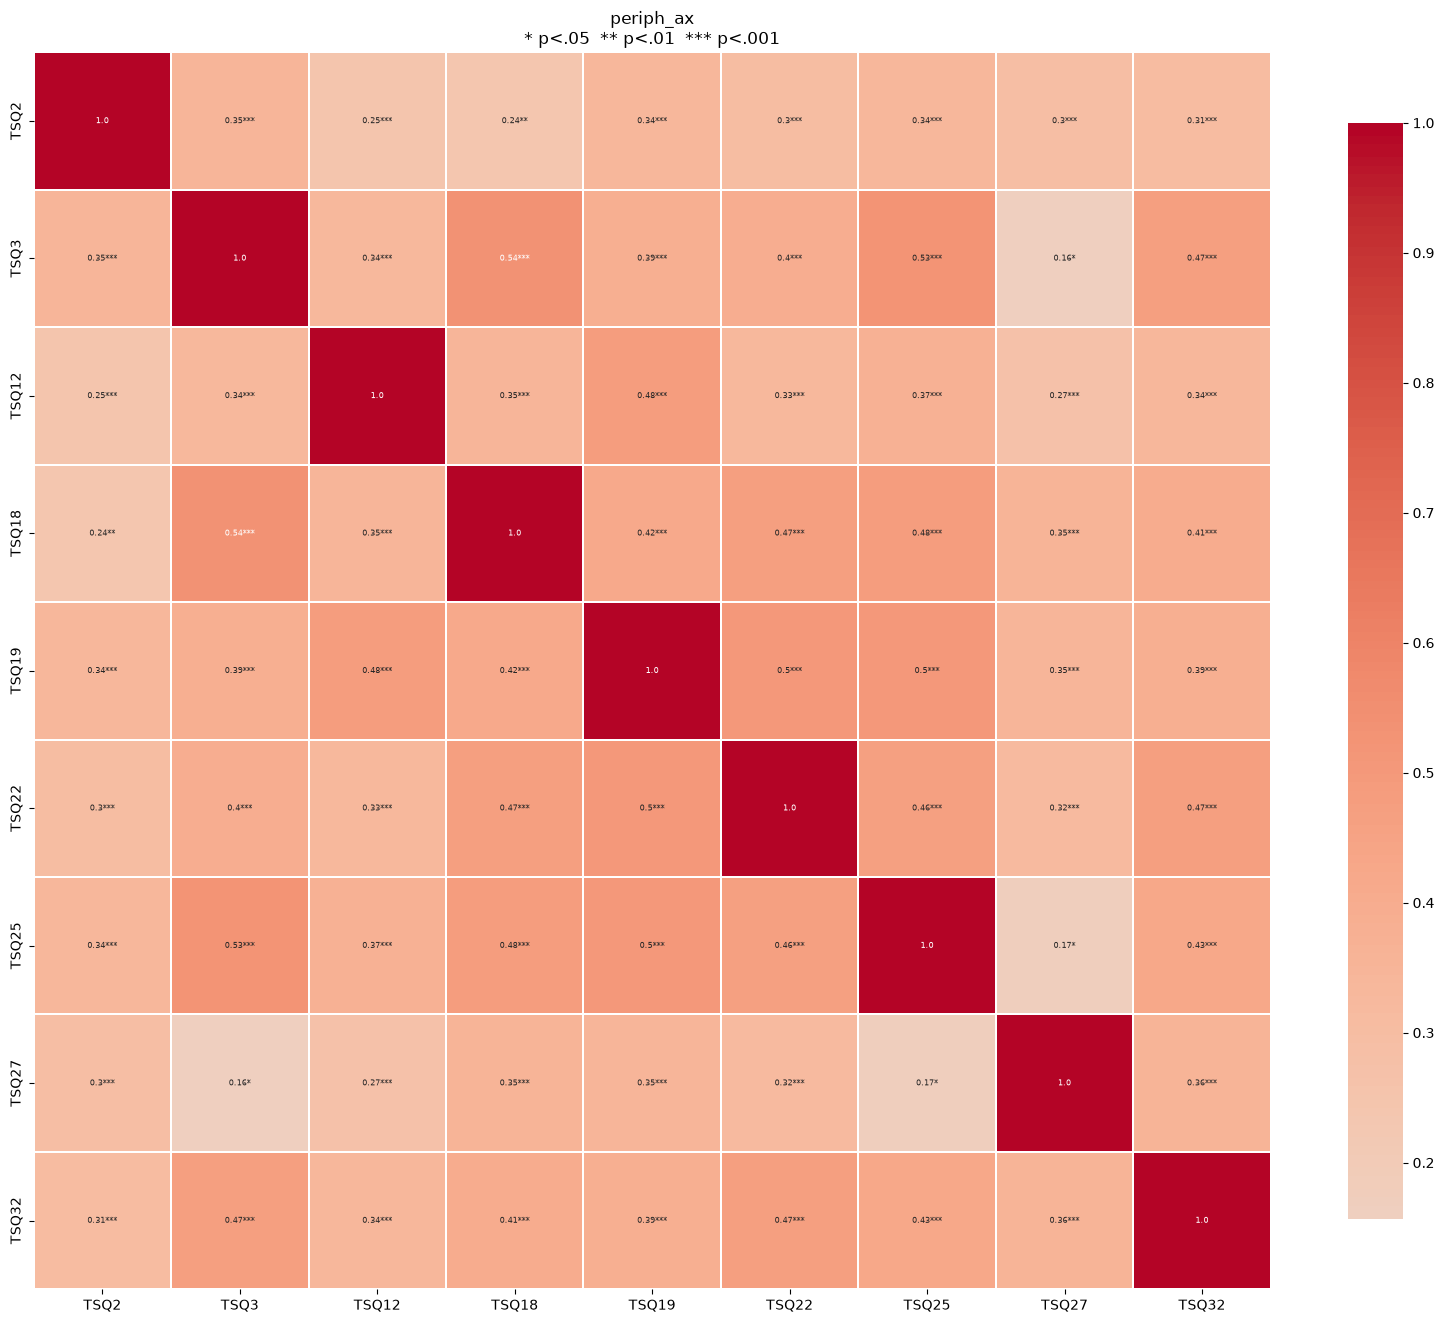

Items conservés (9/9) : ['TSQ2', 'TSQ3', 'TSQ12', 'TSQ18', 'TSQ19', 'TSQ22', 'TSQ25', 'TSQ27', 'TSQ32']
Items retirés (0) : []

========================= periph_sz =========================


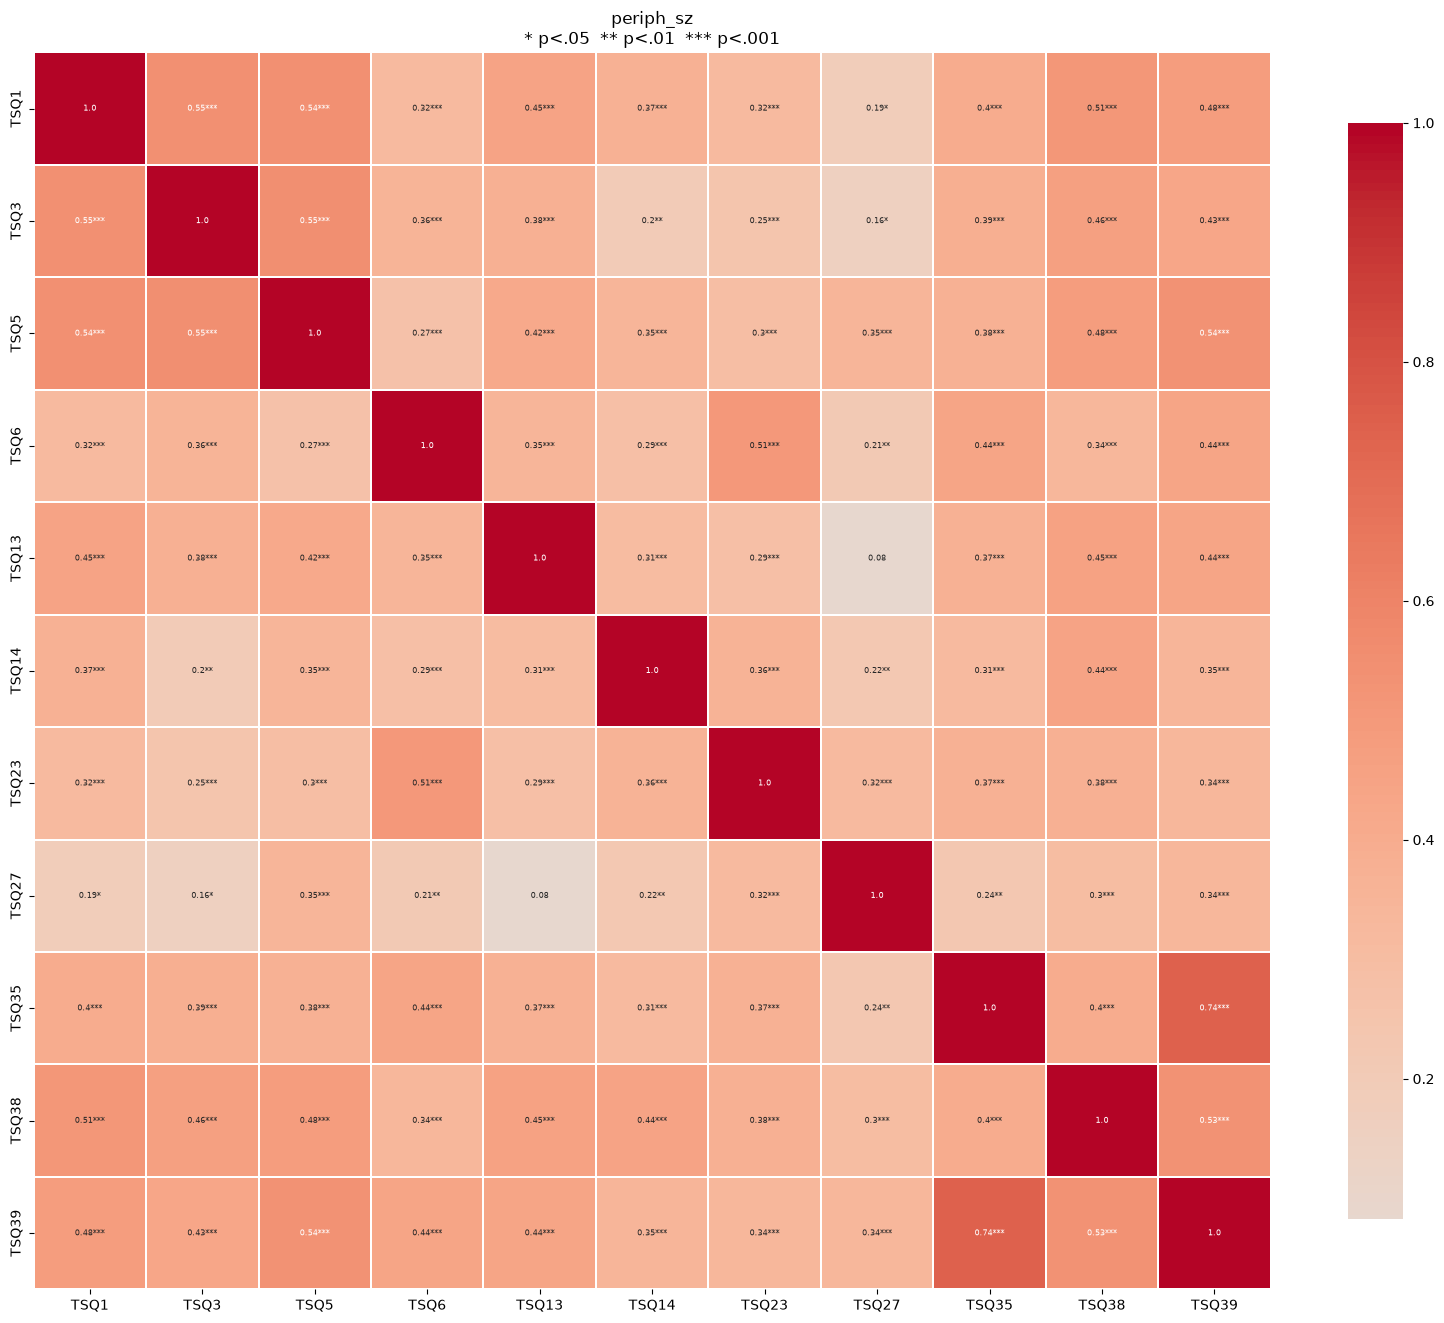

Items conservés (10/11) : ['TSQ1', 'TSQ3', 'TSQ5', 'TSQ6', 'TSQ13', 'TSQ14', 'TSQ23', 'TSQ27', 'TSQ35', 'TSQ38']
Items retirés (1) : ['TSQ39']

========================= periph_mdd =========================


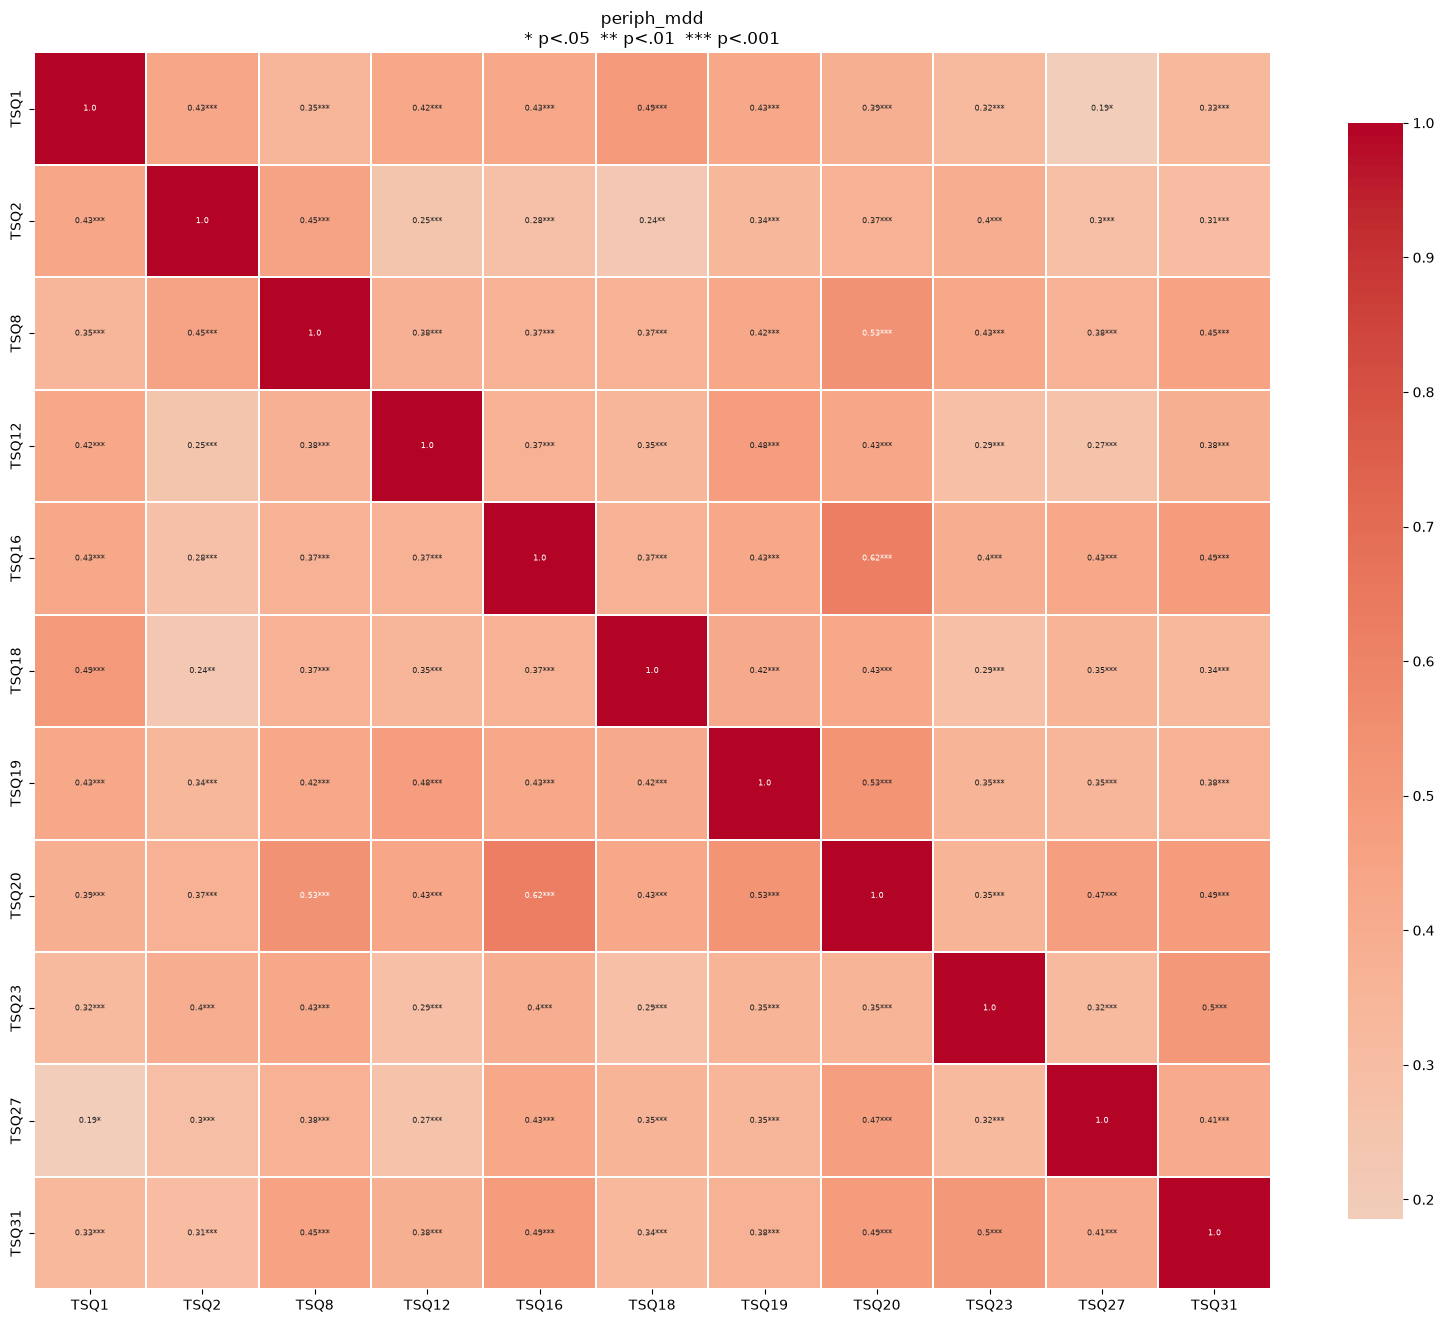

Items conservés (11/11) : ['TSQ1', 'TSQ2', 'TSQ8', 'TSQ12', 'TSQ16', 'TSQ18', 'TSQ19', 'TSQ20', 'TSQ23', 'TSQ27', 'TSQ31']
Items retirés (0) : []

========================= periph_man =========================


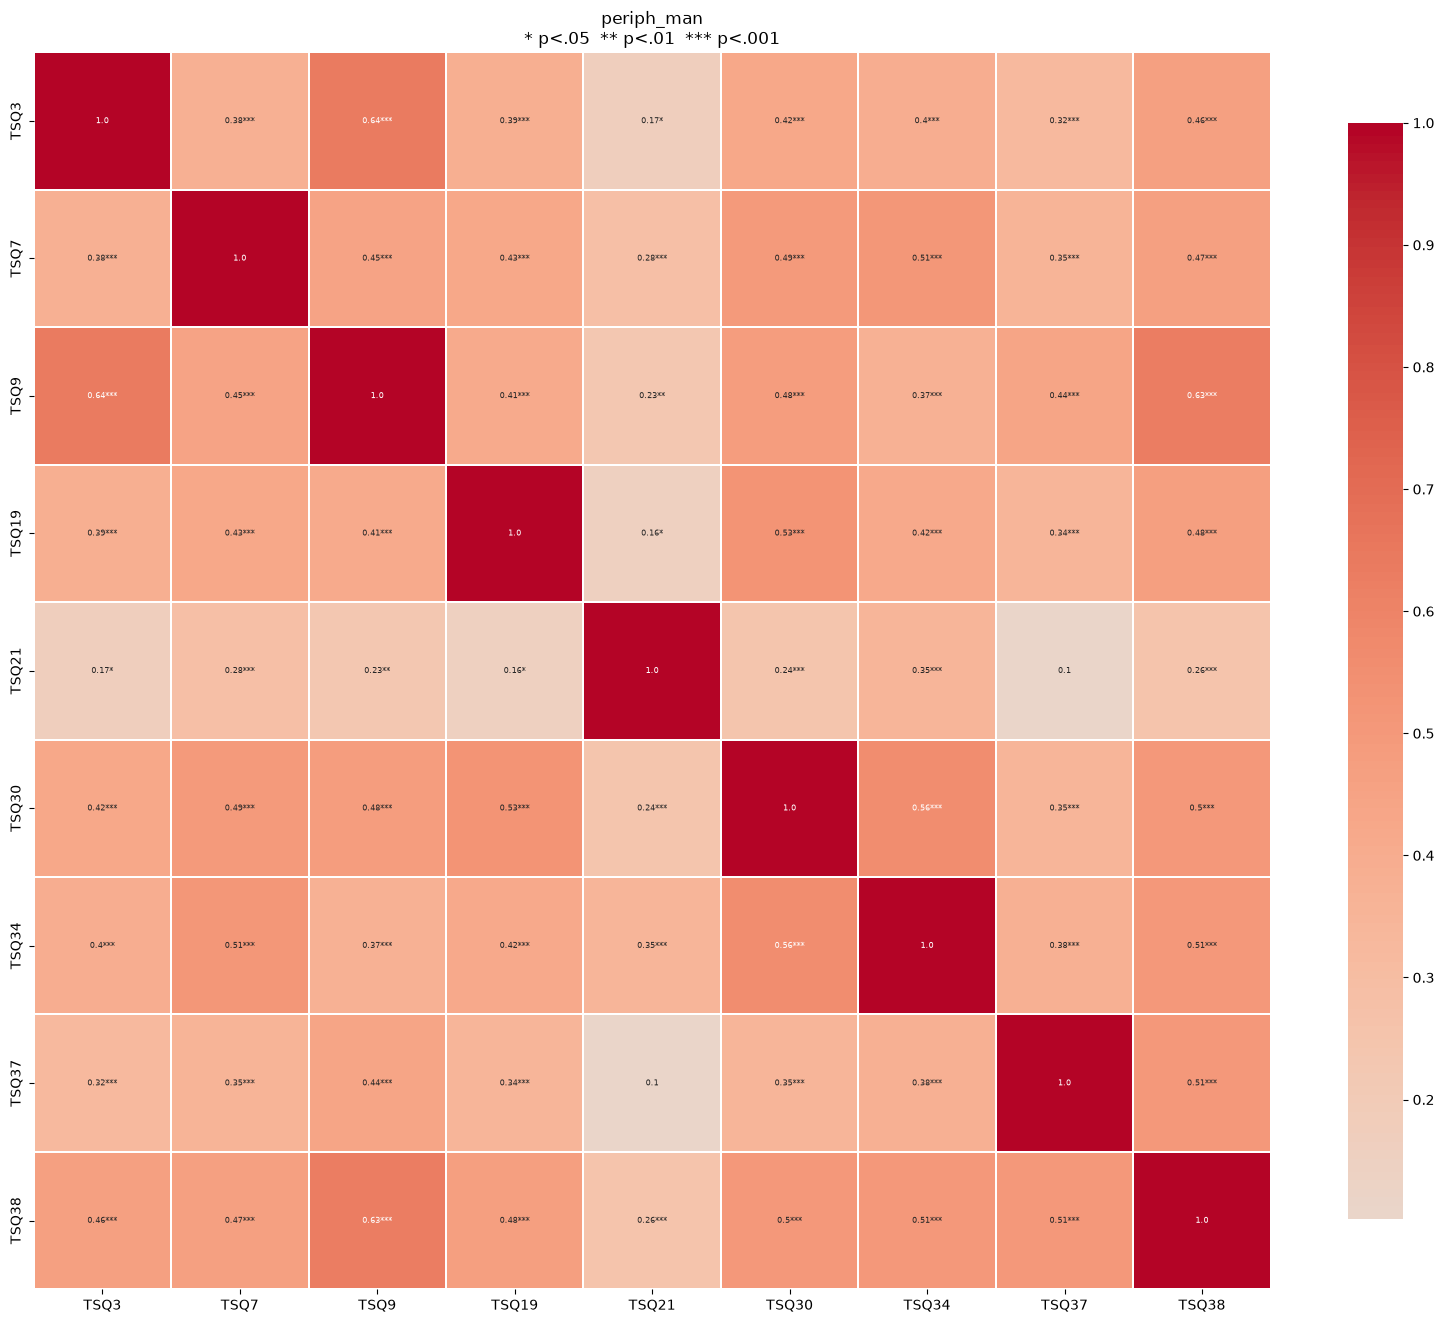

Items conservés (9/9) : ['TSQ3', 'TSQ7', 'TSQ9', 'TSQ19', 'TSQ21', 'TSQ30', 'TSQ34', 'TSQ37', 'TSQ38']
Items retirés (0) : []

========================= periph_ptsd =========================


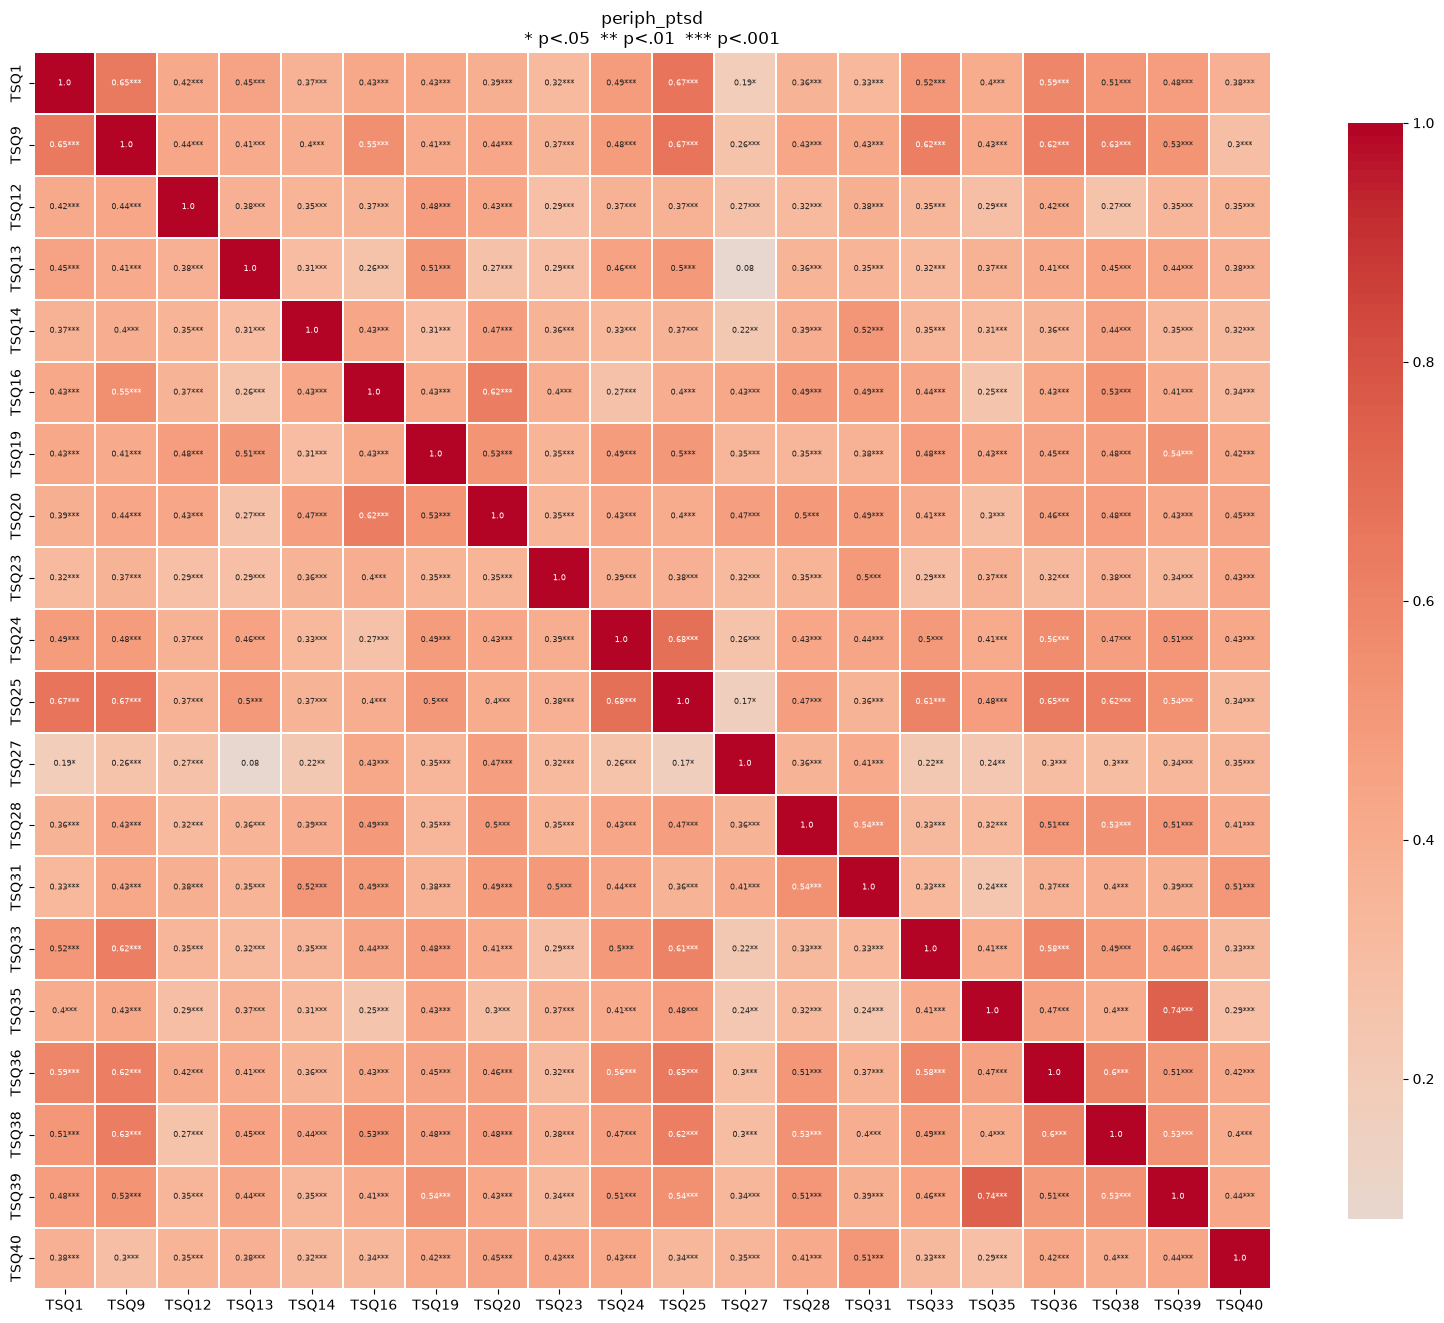

Items conservés (17/20) : ['TSQ1', 'TSQ12', 'TSQ13', 'TSQ14', 'TSQ16', 'TSQ19', 'TSQ20', 'TSQ23', 'TSQ24', 'TSQ27', 'TSQ28', 'TSQ31', 'TSQ33', 'TSQ35', 'TSQ36', 'TSQ38', 'TSQ40']
Items retirés (3) : ['TSQ9', 'TSQ25', 'TSQ39']


In [13]:
from correl_TSQ import compute_tsq_corr, reduce_correlated_features

resultats_corr = {}

for nom, df_subset in sous_echelles.items():
    print(f"\n{'='*25} {nom} {'='*25}")

    items = list(df_subset.columns)

    # Matrice de corrélation + heatmap pour chq sous-échelle
    compute_tsq_corr(df_all, items=items, title=nom)

    # greedy glouton pour enlever kes items qui covarient entre eux, pour chq sous echelle
    selected_items = reduce_correlated_features(df_all, items, threshold=0.65)
    dropped_items = [i for i in items if i not in selected_items]

    print(f"Items conservés ({len(selected_items)}/{len(items)}) :", selected_items)
    print(f"Items retirés ({len(dropped_items)}) :", dropped_items)

    resultats_corr[nom] = {
        "items_initiaux": items,
        "selected_items": selected_items,
        "dropped_items": dropped_items,
    }

In [14]:
sous_echelles_red = {}
sous_echelles_PD_red = {}

for nom, df_sains in sous_echelles.items():
    dropped = resultats_corr[nom]["dropped_items"] + ["score_total"]

    df_sains_red = df_sains.drop(columns=dropped, errors="ignore")
    df_pd_red = sous_echelles_PD[f"{nom}_PD"].drop(columns=dropped, errors="ignore")

    sous_echelles_red[nom] = df_sains_red
    sous_echelles_PD_red[f"{nom}_PD"] = df_pd_red

    print(f"{nom}: {df_sains.shape[1]} → {df_sains_red.shape[1]} items "
          f"(retirés: {dropped if dropped else 'aucun'})")

core_ax: 14 → 12 items (retirés: ['TSQ9', 'TSQ39', 'score_total'])
core_sz: 16 → 16 items (retirés: ['score_total'])
core_mdd: 7 → 6 items (retirés: ['TSQ25', 'score_total'])
core_man: 4 → 2 items (retirés: ['TSQ22', 'TSQ39', 'score_total'])
core_ptsd: 9 → 8 items (retirés: ['TSQ5', 'score_total'])
periph_ax: 9 → 9 items (retirés: ['score_total'])
periph_sz: 11 → 10 items (retirés: ['TSQ39', 'score_total'])
periph_mdd: 11 → 11 items (retirés: ['score_total'])
periph_man: 9 → 9 items (retirés: ['score_total'])
periph_ptsd: 20 → 17 items (retirés: ['TSQ9', 'TSQ25', 'TSQ39', 'score_total'])



========================= core_ax =========================


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


cluster
0    53
1    62
Name: count, dtype: int64
Cluster 0: 53 participants (group 0: 53)
Cluster 1: 62 participants (group 0: 62)

=== Répartition train (fit) ===
0    53
1    62
Name: count, dtype: int64

=== Répartition test (via predict, pas refit) ===
0    28
1    11
Name: count, dtype: int64

=== LogisticRegression ===


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Meilleurs params : {'clf__C': 10, 'clf__penalty': 'l2'}
Meilleur score CV : 0.945
Score sur test set : 0.937

=== SVM_RBF ===


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Meilleurs params : {'clf__C': 100, 'clf__gamma': 0.01}
Meilleur score CV : 0.946
Score sur test set : 0.909

=== RandomForest ===
Meilleurs params : {'clf__max_depth': None, 'clf__min_samples_leaf': 10, 'clf__n_estimators': 100}
Meilleur score CV : 0.947
Score sur test set : 0.846

=== HistGradientBoosting ===
Meilleurs params : {'clf__learning_rate': 0.01, 'clf__max_depth': None, 'clf__max_iter': 400}
Meilleur score CV : 0.936
Score sur test set : 0.909

=== Comparaison des modèles ===
                      CV score  Test score
RandomForest          0.946550    0.845779
SVM_RBF               0.945793    0.909091
LogisticRegression    0.944883    0.936688
HistGradientBoosting  0.935793    0.909091

Meilleur modèle : RandomForest
              precision    recall  f1-score   support

           0       0.90      0.96      0.93        28
           1       0.89      0.73      0.80        11

    accuracy                           0.90        39
   macro avg       0.89      0.85      0.87

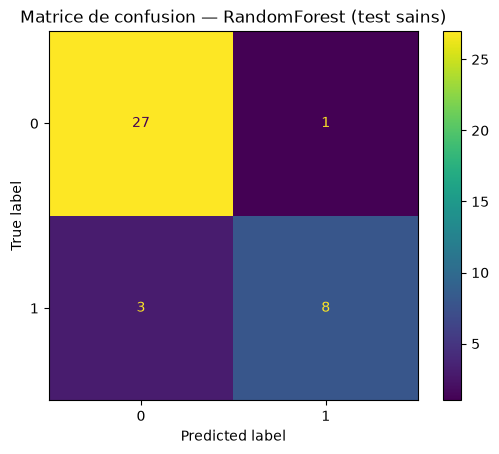

Meilleur modèle pour core_ax : RandomForest

========================= core_sz =========================


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


cluster
0    47
1    68
Name: count, dtype: int64
Cluster 0: 47 participants (group 0: 47)
Cluster 1: 68 participants (group 0: 68)

=== Répartition train (fit) ===
0    47
1    68
Name: count, dtype: int64

=== Répartition test (via predict, pas refit) ===
0     8
1    31
Name: count, dtype: int64

=== LogisticRegression ===


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Meilleurs params : {'clf__C': 1, 'clf__penalty': 'l2'}
Meilleur score CV : 0.935
Score sur test set : 0.921

=== SVM_RBF ===


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Meilleurs params : {'clf__C': 1, 'clf__gamma': 1}
Meilleur score CV : 0.942
Score sur test set : 0.796

=== RandomForest ===
Meilleurs params : {'clf__max_depth': None, 'clf__min_samples_leaf': 10, 'clf__n_estimators': 500}
Meilleur score CV : 0.925
Score sur test set : 0.921

=== HistGradientBoosting ===
Meilleurs params : {'clf__learning_rate': 0.01, 'clf__max_depth': None, 'clf__max_iter': 200}
Meilleur score CV : 0.925
Score sur test set : 0.921

=== Comparaison des modèles ===
                      CV score  Test score
SVM_RBF               0.942381    0.796371
LogisticRegression    0.935238    0.921371
RandomForest          0.925238    0.921371
HistGradientBoosting  0.924689    0.921371

Meilleur modèle : SVM_RBF
              precision    recall  f1-score   support

           0       0.83      0.62      0.71         8
           1       0.91      0.97      0.94        31

    accuracy                           0.90        39
   macro avg       0.87      0.80      0.83        39

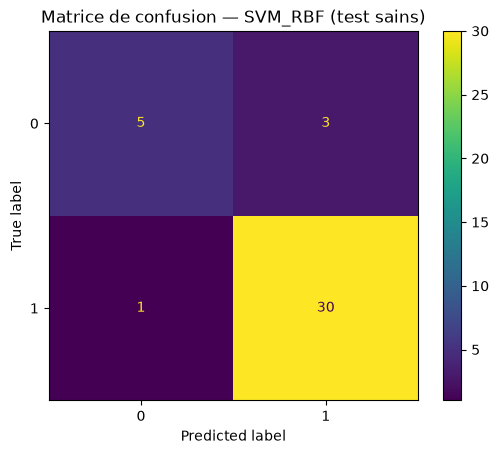

Meilleur modèle pour core_sz : SVM_RBF

========================= core_mdd =========================


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


cluster
0    74
1    41
Name: count, dtype: int64
Cluster 0: 74 participants (group 0: 74)
Cluster 1: 41 participants (group 0: 41)

=== Répartition train (fit) ===
0    74
1    41
Name: count, dtype: int64

=== Répartition test (via predict, pas refit) ===
0    29
1    10
Name: count, dtype: int64

=== LogisticRegression ===


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Meilleurs params : {'clf__C': 1, 'clf__penalty': 'l2'}
Meilleur score CV : 0.968
Score sur test set : 0.95

=== SVM_RBF ===


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Meilleurs params : {'clf__C': 10, 'clf__gamma': 1}
Meilleur score CV : 0.968
Score sur test set : 0.85

=== RandomForest ===
Meilleurs params : {'clf__max_depth': None, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 100}
Meilleur score CV : 0.956
Score sur test set : 0.85

=== HistGradientBoosting ===
Meilleurs params : {'clf__learning_rate': 0.05, 'clf__max_depth': None, 'clf__max_iter': 100}
Meilleur score CV : 0.956
Score sur test set : 0.9

=== Comparaison des modèles ===
                      CV score  Test score
LogisticRegression    0.968333        0.95
SVM_RBF               0.967500        0.85
RandomForest          0.955833        0.85
HistGradientBoosting  0.955833        0.90

Meilleur modèle : LogisticRegression
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        29
           1       1.00      0.90      0.95        10

    accuracy                           0.97        39
   macro avg       0.98      0.95      0.97   

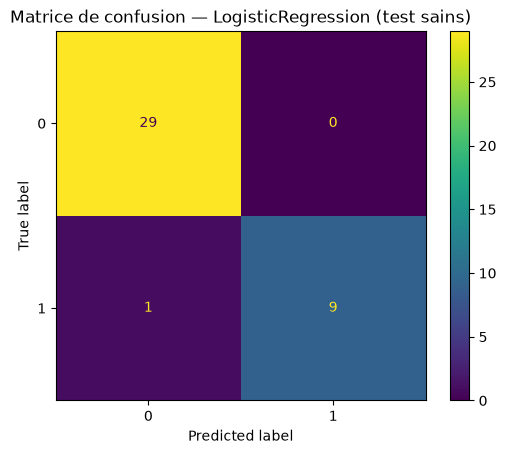

Meilleur modèle pour core_mdd : LogisticRegression

========================= core_man =========================


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


cluster
0    62
1    53
Name: count, dtype: int64
Cluster 0: 62 participants (group 0: 62)
Cluster 1: 53 participants (group 0: 53)

=== Répartition train (fit) ===
0    62
1    53
Name: count, dtype: int64

=== Répartition test (via predict, pas refit) ===
0    24
1    15
Name: count, dtype: int64

=== LogisticRegression ===


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Meilleurs params : {'clf__C': 100, 'clf__penalty': 'l2'}
Meilleur score CV : 1.0
Score sur test set : 1.0

=== SVM_RBF ===


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Meilleurs params : {'clf__C': 100, 'clf__gamma': 'scale'}
Meilleur score CV : 0.992
Score sur test set : 1.0

=== RandomForest ===
Meilleurs params : {'clf__max_depth': None, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 100}
Meilleur score CV : 0.992
Score sur test set : 0.979

=== HistGradientBoosting ===
Meilleurs params : {'clf__learning_rate': 0.01, 'clf__max_depth': None, 'clf__max_iter': 200}
Meilleur score CV : 0.972
Score sur test set : 0.958

=== Comparaison des modèles ===
                      CV score  Test score
LogisticRegression    1.000000    1.000000
SVM_RBF               0.991667    1.000000
RandomForest          0.991667    0.979167
HistGradientBoosting  0.971667    0.958333

Meilleur modèle : LogisticRegression
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        24
           1       1.00      1.00      1.00        15

    accuracy                           1.00        39
   macro avg       1.00      1.00    

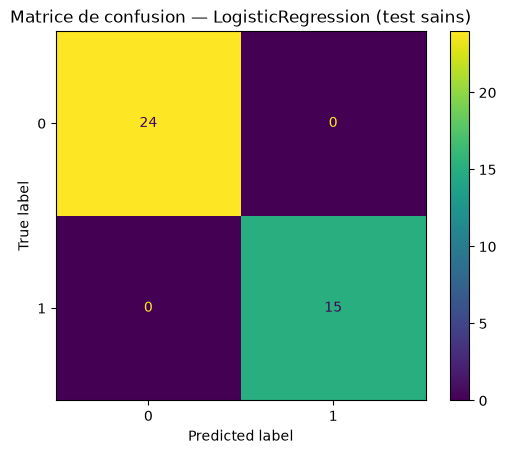

Meilleur modèle pour core_man : LogisticRegression

========================= core_ptsd =========================


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


cluster
0    53
1    62
Name: count, dtype: int64
Cluster 0: 53 participants (group 0: 53)
Cluster 1: 62 participants (group 0: 62)

=== Répartition train (fit) ===
0    53
1    62
Name: count, dtype: int64

=== Répartition test (via predict, pas refit) ===
0    10
1    29
Name: count, dtype: int64

=== LogisticRegression ===


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Meilleurs params : {'clf__C': 100, 'clf__penalty': 'l2'}
Meilleur score CV : 1.0
Score sur test set : 0.983

=== SVM_RBF ===


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Meilleurs params : {'clf__C': 1, 'clf__gamma': 1}
Meilleur score CV : 1.0
Score sur test set : 0.95

=== RandomForest ===
Meilleurs params : {'clf__max_depth': None, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 100}
Meilleur score CV : 0.982
Score sur test set : 0.883

=== HistGradientBoosting ===
Meilleurs params : {'clf__learning_rate': 0.05, 'clf__max_depth': None, 'clf__max_iter': 200}
Meilleur score CV : 0.982
Score sur test set : 0.9

=== Comparaison des modèles ===
                      CV score  Test score
LogisticRegression    1.000000    0.982759
SVM_RBF               1.000000    0.950000
RandomForest          0.981818    0.882759
HistGradientBoosting  0.981818    0.900000

Meilleur modèle : LogisticRegression
              precision    recall  f1-score   support

           0       0.91      1.00      0.95        10
           1       1.00      0.97      0.98        29

    accuracy                           0.97        39
   macro avg       0.95      0.98      0.97     

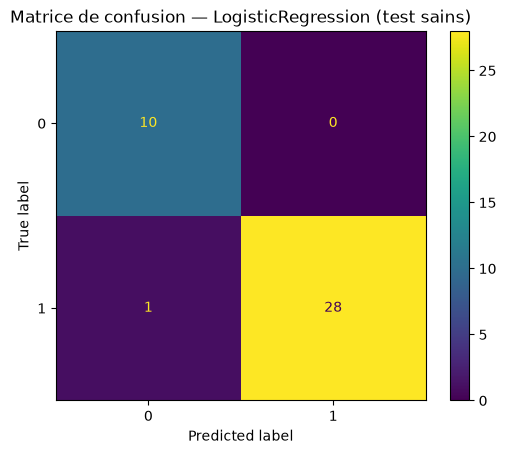

Meilleur modèle pour core_ptsd : LogisticRegression

========================= periph_ax =========================


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


cluster
0    47
1    68
Name: count, dtype: int64
Cluster 0: 47 participants (group 0: 47)
Cluster 1: 68 participants (group 0: 68)

=== Répartition train (fit) ===
0    47
1    68
Name: count, dtype: int64

=== Répartition test (via predict, pas refit) ===
0    11
1    28
Name: count, dtype: int64

=== LogisticRegression ===


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Meilleurs params : {'clf__C': 1, 'clf__penalty': 'l2'}
Meilleur score CV : 0.958
Score sur test set : 0.937

=== SVM_RBF ===


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Meilleurs params : {'clf__C': 100, 'clf__gamma': 0.01}
Meilleur score CV : 0.944
Score sur test set : 0.937

=== RandomForest ===
Meilleurs params : {'clf__max_depth': None, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 100}
Meilleur score CV : 0.944
Score sur test set : 0.955

=== HistGradientBoosting ===
Meilleurs params : {'clf__learning_rate': 0.01, 'clf__max_depth': None, 'clf__max_iter': 200}
Meilleur score CV : 0.933
Score sur test set : 0.955

=== Comparaison des modèles ===
                      CV score  Test score
LogisticRegression    0.958022    0.936688
SVM_RBF               0.944054    0.936688
RandomForest          0.944054    0.954545
HistGradientBoosting  0.932943    0.954545

Meilleur modèle : LogisticRegression
              precision    recall  f1-score   support

           0       0.91      0.91      0.91        11
           1       0.96      0.96      0.96        28

    accuracy                           0.95        39
   macro avg       0.94      0.94     

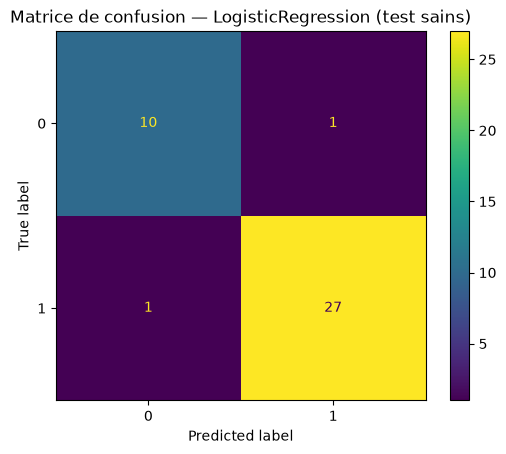

Meilleur modèle pour periph_ax : LogisticRegression

========================= periph_sz =========================


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


cluster
0    62
1    53
Name: count, dtype: int64
Cluster 0: 62 participants (group 0: 62)
Cluster 1: 53 participants (group 0: 53)

=== Répartition train (fit) ===
0    62
1    53
Name: count, dtype: int64

=== Répartition test (via predict, pas refit) ===
0    29
1    10
Name: count, dtype: int64

=== LogisticRegression ===
Meilleurs params : {'clf__C': 0.1, 'clf__penalty': 'l2'}
Meilleur score CV : 0.907
Score sur test set : 0.966

=== SVM_RBF ===


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Meilleurs params : {'clf__C': 0.1, 'clf__gamma': 0.1}
Meilleur score CV : 0.925
Score sur test set : 0.966

=== RandomForest ===
Meilleurs params : {'clf__max_depth': None, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 100}
Meilleur score CV : 0.901
Score sur test set : 1.0

=== HistGradientBoosting ===
Meilleurs params : {'clf__learning_rate': 0.1, 'clf__max_depth': None, 'clf__max_iter': 400}
Meilleur score CV : 0.909
Score sur test set : 1.0

=== Comparaison des modèles ===
                      CV score  Test score
SVM_RBF               0.925256    0.965517
HistGradientBoosting  0.909242    1.000000
LogisticRegression    0.906923    0.965517
RandomForest          0.900793    1.000000

Meilleur modèle : SVM_RBF
              precision    recall  f1-score   support

           0       1.00      0.93      0.96        29
           1       0.83      1.00      0.91        10

    accuracy                           0.95        39
   macro avg       0.92      0.97      0.94        39
w

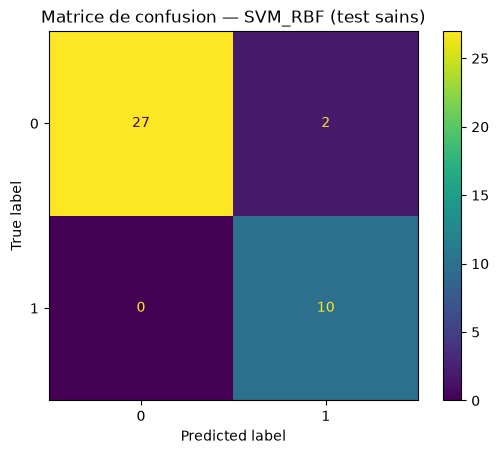

Meilleur modèle pour periph_sz : SVM_RBF

========================= periph_mdd =========================


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


cluster
0    70
1    45
Name: count, dtype: int64
Cluster 0: 70 participants (group 0: 70)
Cluster 1: 45 participants (group 0: 45)

=== Répartition train (fit) ===
0    70
1    45
Name: count, dtype: int64

=== Répartition test (via predict, pas refit) ===
0    28
1    11
Name: count, dtype: int64

=== LogisticRegression ===


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Meilleurs params : {'clf__C': 10, 'clf__penalty': 'l2'}
Meilleur score CV : 0.942
Score sur test set : 0.864

=== SVM_RBF ===


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Meilleurs params : {'clf__C': 10, 'clf__gamma': 'scale'}
Meilleur score CV : 0.927
Score sur test set : 0.818

=== RandomForest ===
Meilleurs params : {'clf__max_depth': None, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 500}
Meilleur score CV : 0.927
Score sur test set : 0.864

=== HistGradientBoosting ===
Meilleurs params : {'clf__learning_rate': 0.01, 'clf__max_depth': None, 'clf__max_iter': 400}
Meilleur score CV : 0.906
Score sur test set : 0.864

=== Comparaison des modèles ===
                      CV score  Test score
LogisticRegression    0.942063    0.863636
RandomForest          0.926984    0.863636
SVM_RBF               0.926984    0.818182
HistGradientBoosting  0.905556    0.863636

Meilleur modèle : LogisticRegression
              precision    recall  f1-score   support

           0       0.90      1.00      0.95        28
           1       1.00      0.73      0.84        11

    accuracy                           0.92        39
   macro avg       0.95      0.86   

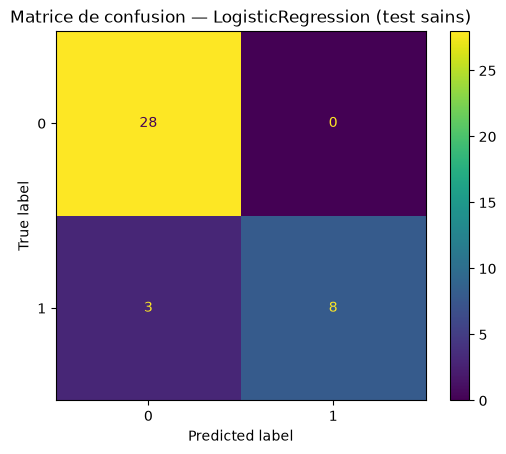

Meilleur modèle pour periph_mdd : LogisticRegression

========================= periph_man =========================


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


cluster
0    48
1    67
Name: count, dtype: int64
Cluster 0: 48 participants (group 0: 48)
Cluster 1: 67 participants (group 0: 67)

=== Répartition train (fit) ===
0    48
1    67
Name: count, dtype: int64

=== Répartition test (via predict, pas refit) ===
0    13
1    26
Name: count, dtype: int64

=== LogisticRegression ===
Meilleurs params : {'clf__C': 100, 'clf__penalty': 'l2'}
Meilleur score CV : 0.966
Score sur test set : 0.962

=== SVM_RBF ===


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Meilleurs params : {'clf__C': 100, 'clf__gamma': 0.1}
Meilleur score CV : 0.953
Score sur test set : 0.981

=== RandomForest ===
Meilleurs params : {'clf__max_depth': None, 'clf__min_samples_leaf': 10, 'clf__n_estimators': 300}
Meilleur score CV : 0.927
Score sur test set : 0.942

=== HistGradientBoosting ===
Meilleurs params : {'clf__learning_rate': 0.1, 'clf__max_depth': None, 'clf__max_iter': 400}
Meilleur score CV : 0.922
Score sur test set : 0.942

=== Comparaison des modèles ===
                      CV score  Test score
LogisticRegression    0.965714    0.961538
SVM_RBF               0.952857    0.980769
RandomForest          0.926911    0.942308
HistGradientBoosting  0.922393    0.942308

Meilleur modèle : LogisticRegression
              precision    recall  f1-score   support

           0       1.00      0.92      0.96        13
           1       0.96      1.00      0.98        26

    accuracy                           0.97        39
   macro avg       0.98      0.96      

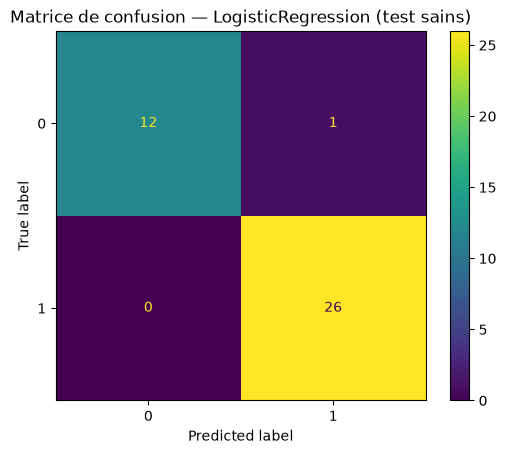

Meilleur modèle pour periph_man : LogisticRegression

========================= periph_ptsd =========================


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


cluster
0    62
1    53
Name: count, dtype: int64
Cluster 0: 62 participants (group 0: 62)
Cluster 1: 53 participants (group 0: 53)

=== Répartition train (fit) ===
0    62
1    53
Name: count, dtype: int64

=== Répartition test (via predict, pas refit) ===
0    31
1     8
Name: count, dtype: int64

=== LogisticRegression ===


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Meilleurs params : {'clf__C': 10, 'clf__penalty': 'l2'}
Meilleur score CV : 0.954
Score sur test set : 0.984

=== SVM_RBF ===


c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Meilleurs params : {'clf__C': 100, 'clf__gamma': 1}
Meilleur score CV : 0.973
Score sur test set : 0.984

=== RandomForest ===
Meilleurs params : {'clf__max_depth': 5, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 500}
Meilleur score CV : 0.956
Score sur test set : 0.812

=== HistGradientBoosting ===
Meilleurs params : {'clf__learning_rate': 0.05, 'clf__max_depth': None, 'clf__max_iter': 100}
Meilleur score CV : 0.947
Score sur test set : 0.875

=== Comparaison des modèles ===
                      CV score  Test score
SVM_RBF               0.973217    0.983871
RandomForest          0.955524    0.812500
LogisticRegression    0.953974    0.983871
HistGradientBoosting  0.947191    0.875000

Meilleur modèle : SVM_RBF
              precision    recall  f1-score   support

           0       1.00      0.97      0.98        31
           1       0.89      1.00      0.94         8

    accuracy                           0.97        39
   macro avg       0.94      0.98      0.96        39
w

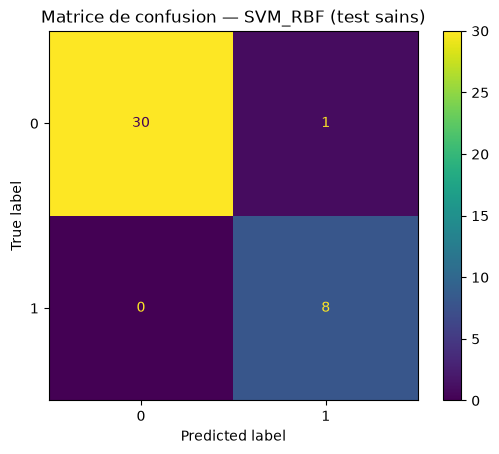

Meilleur modèle pour periph_ptsd : SVM_RBF


In [15]:
from testclust import split_umap_clustering_train_test
from pipeline_ML import train_and_compare_classifiers, apply_to_patients

resultats_sous_echelles = {}

for nom, df_sains in sous_echelles_red.items():
    print(f"\n{'='*25} {nom} {'='*25}")

    split_result = split_umap_clustering_train_test(
        df_sains, n_clusters=2, test_size=0.25, random_state=42, group=group,
    )

    X_train, X_test = split_result["X_train_2d"], split_result["X_test_2d"]
    y_train, y_test = split_result["y_train"], split_result["y_test"]

    results, summary, best_model_name, best_model = train_and_compare_classifiers(
        X_train, y_train, X_test, y_test,
        scoring="balanced_accuracy",
        plot_curves=False,   
    )

    resultats_sous_echelles[nom] = {
        "split_result": split_result,
        "results": results,
        "summary": summary,
        "best_model_name": best_model_name,
        "best_model": best_model,
    }

    print(f"Meilleur modèle pour {nom} : {best_model_name}")

In [16]:
recap = []
for nom, r in resultats_sous_echelles.items():
    best_row = r["summary"].loc[r["best_model_name"]]
    recap.append({
        "sous_echelle": nom,
        "n_items": r["split_result"]["df_train"].shape[1] - (1 if "group" in r["split_result"]["df_train"].columns else 0),
        "best_model": r["best_model_name"],
        "cv_score": round(best_row["CV score"], 3),
        "test_score": round(best_row["Test score"], 3),
    })

df_recap = pd.DataFrame(recap).sort_values("test_score", ascending=False)
df_recap

,sous_echelle,n_items,best_model,cv_score,test_score
3,core_man,2,LogisticRegression,1.000,1.000
9,periph_ptsd,17,SVM_RBF,0.973,0.984
4,core_ptsd,8,LogisticRegression,1.000,0.983
6,periph_sz,10,SVM_RBF,0.925,0.966
8,periph_man,9,LogisticRegression,0.966,0.962
2,core_mdd,6,LogisticRegression,0.968,0.950
5,periph_ax,9,LogisticRegression,0.958,0.937
7,periph_mdd,11,LogisticRegression,0.942,0.864
0,core_ax,12,RandomForest,0.947,0.846
1,core_sz,16,SVM_RBF,0.942,0.796


In [17]:
from pipeline_ML import apply_to_patients

for nom, r in resultats_sous_echelles.items():
    print(f"\n{'='*25} {nom} {'='*25}")

    df_patients = sous_echelles_PD_red[f"{nom}_PD"]

    df_patients_pred = apply_to_patients(
        r["best_model"],
        r["split_result"]["res_train"].umap_2d_model,   # fit sur train, jamais sur test ni patients
        df_patients,
    )

    r["df_patients_pred"] = df_patients_pred   # stocké dans le dict pour usage/recap ultérieur

    print(df_patients_pred["predicted_cluster"].value_counts().sort_index())


========================= core_ax =========================


predicted_cluster
0    17
1    14
Name: count, dtype: int64

========================= core_sz =========================
predicted_cluster
0    16
1    15
Name: count, dtype: int64

========================= core_mdd =========================
predicted_cluster
0    14
1    17
Name: count, dtype: int64

========================= core_man =========================
predicted_cluster
0    17
1    14
Name: count, dtype: int64

========================= core_ptsd =========================
predicted_cluster
0    20
1    11
Name: count, dtype: int64

========================= periph_ax =========================
predicted_cluster
0    18
1    13
Name: count, dtype: int64

========================= periph_sz =========================
predicted_cluster
0    15
1    16
Name: count, dtype: int64

========================= periph_mdd =========================
predicted_cluster
0    15
1    16
Name: count, dtype: int64

========================= periph_man =========================
predicted_cluster


# Récap des meilleurs modeles trouvés pour chq sous echelle

In [18]:
recap = []
for nom, r in resultats_sous_echelles.items():
    best_row = r["summary"].loc[r["best_model_name"]]
    patient_counts = r["df_patients_pred"]["predicted_cluster"].value_counts().sort_index()
    recap.append({
        "sous_echelle": nom,
        "best_model": r["best_model_name"],
        "cv_score": round(best_row["CV score"], 3),
        "test_score": round(best_row["Test score"], 3),
        "patients_cluster_0": patient_counts.get(0, 0),
        "patients_cluster_1": patient_counts.get(1, 0),
    })

df_recap = pd.DataFrame(recap).sort_values("test_score", ascending=False)
df_recap

,sous_echelle,best_model,cv_score,test_score,patients_cluster_0,patients_cluster_1
3,core_man,LogisticRegression,1.000,1.000,17,14
9,periph_ptsd,SVM_RBF,0.973,0.984,11,20
4,core_ptsd,LogisticRegression,1.000,0.983,20,11
6,periph_sz,SVM_RBF,0.925,0.966,15,16
8,periph_man,LogisticRegression,0.966,0.962,21,10
2,core_mdd,LogisticRegression,0.968,0.950,14,17
5,periph_ax,LogisticRegression,0.958,0.937,18,13
7,periph_mdd,LogisticRegression,0.942,0.864,15,16
0,core_ax,RandomForest,0.947,0.846,17,14
1,core_sz,SVM_RBF,0.942,0.796,16,15


# Visualisation de la classification des participants avec diag dans l'espace UMAP

In [21]:
import pandas as pd
import plotly.express as px

for nom, r in resultats_sous_echelles.items():
    split_result = r["split_result"]
    res_train = split_result["res_train"]
    df_patients_pred = r["df_patients_pred"]
    df_patients = sous_echelles_PD_red[f"{nom}_PD"]

    X_patients_umap = res_train.umap_2d_model.transform(df_patients.values)

    hover_train = [f"Participant {i}" for i in split_result["df_train"].index]
    hover_test  = [f"Participant {i}" for i in split_result["df_test"].index]
    hover_diag  = [f"Participant {i}" for i in df_patients.index]

    df_plot = pd.concat([
        pd.DataFrame({
            "x": split_result["X_train_2d"][:, 0], "y": split_result["X_train_2d"][:, 1],
            "cluster": split_result["y_train"].astype(str),
            "type": "Sains (train)",
            "participant": hover_train,
        }),
        pd.DataFrame({
            "x": split_result["X_test_2d"][:, 0], "y": split_result["X_test_2d"][:, 1],
            "cluster": split_result["y_test"].astype(str),
            "type": "Sains (test)",
            "participant": hover_test,
        }),
        pd.DataFrame({
            "x": X_patients_umap[:, 0], "y": X_patients_umap[:, 1],
            "cluster": df_patients_pred["predicted_cluster"].astype(str),
            "type": "Diag",
            "participant": hover_diag,
        }),
    ], ignore_index=True)

    fig = px.scatter(
        df_plot, x="x", y="y",
        color="cluster", symbol="type",
        color_discrete_map={"0": "#A777F1", "1": "#FC6955"},
        symbol_map={"Sains (train)": "circle", "Sains (test)": "circle-open", "Diag": "triangle-up"},
        opacity=0.7,
        hover_name="participant",
        title=f"{nom} — Sains (train/test) et patients projetés dans l'espace UMAP (fit sur train)",
    )

    for trace in fig.data:
        if "Diag" in trace.name:
            trace.marker.line = dict(width=1, color="black")

    fig.show(renderer="browser")

# Regardons si le profil des participants avec diag mis dans le cluster 1 correspond à leur diag en fonction des sous echelles

In [25]:
from scoring_PD import calculer_scores_tsq

# Scores officiels (sur les 40 items ORIGINAUX, pas les items réduits utilisés pour le clustering)
df_scores_PD = calculer_scores_tsq(df_TSQ_PD_raw)

# Correspondance entre le nom de tes sous-échelles (notebook) et les colonnes de scoring_PD.py
mapping_scores = {
    "core_ax":    "core_an", "core_sz":    "core_sz", "core_mdd":   "core_md",
    "core_man":   "core_ma", "core_ptsd":  "core_pt",
    "periph_ax":  "per_an",  "periph_sz":  "per_sz",  "periph_mdd": "per_md",
    "periph_man": "per_ma",  "periph_ptsd":"per_pt",
}

col_name = df_PD.columns[18]
diag = df_PD[col_name]

rows = []
for nom, r in resultats_sous_echelles.items():
    df_patients_pred = r["df_patients_pred"]
    col_score = mapping_scores[nom]

    for participant in df_patients_pred.index:
        rows.append({
            "participant": participant,
            "diagnostic": diag.get(participant),
            "sous_echelle": nom,
            "cluster": df_patients_pred.loc[participant, "predicted_cluster"],
            "score": round(df_scores_PD.loc[participant, col_score], 3),
        })

df_scores_patients = pd.DataFrame(rows)
df_scores_patients

,participant,diagnostic,sous_echelle,cluster,score
0,2,TDAH\nDépression\nAnxiété chronique,core_ax,0,0.271
1,4,Trouble anxieux,core_ax,1,0.550
2,11,Depression,core_ax,0,0.271
3,13,Dépression,core_ax,0,0.657
4,20,TROUBLE BIPOLAIRE TYPE 1,core_ax,1,0.386
...,...,...,...,...,...
305,287,borderline,periph_ptsd,1,0.315
306,290,"Trouble anxieux généralisé, anxiété sociale, s...",periph_ptsd,1,0.605
307,296,Depression reactionnelle,periph_ptsd,0,0.140
308,300,Bipolarité,periph_ptsd,0,0.075


In [26]:
from scoring_PD import calculer_scores_tsq

# Scores officiels calculés une seule fois, sur les 40 items ORIGINAUX
df_scores_PD = calculer_scores_tsq(df_TSQ_PD_raw)

# Correspondance nom sous-échelle (notebook) → colonne de score (scoring_PD.py)
mapping_scores = {
    "core_ax":    "core_an", "core_sz":    "core_sz", "core_mdd":   "core_md",
    "core_man":   "core_ma", "core_ptsd":  "core_pt",
    "periph_ax":  "per_an",  "periph_sz":  "per_sz",  "periph_mdd": "per_md",
    "periph_man": "per_ma",  "periph_ptsd":"per_pt",
}

col_name = df_PD.columns[18]
print(f"Colonne diag : {col_name}")

diag = df_PD[col_name]   # Series indexée par participant

repartition_patients = {}

for nom, r in resultats_sous_echelles.items():
    df_patients_pred = r["df_patients_pred"]
    col_score = mapping_scores[nom]
    score = df_scores_PD[col_score]   # Series indexée par participant, pour cette sous-échelle

    cluster_0_idx = df_patients_pred[df_patients_pred["predicted_cluster"] == 0].index
    cluster_1_idx = df_patients_pred[df_patients_pred["predicted_cluster"] == 1].index

    cluster_0 = list(zip(cluster_0_idx, diag.reindex(cluster_0_idx), score.reindex(cluster_0_idx)))
    cluster_1 = list(zip(cluster_1_idx, diag.reindex(cluster_1_idx), score.reindex(cluster_1_idx)))

    repartition_patients[nom] = {
        "cluster_0": cluster_0,
        "cluster_1": cluster_1,
    }

    print(f"\n{'='*25} {nom} {'='*25}")
    print(f"Cluster 0 ({len(cluster_0)} patients) :")
    for participant, d, s in cluster_0:
        print(f"  Participant {participant} → {d} | score = {round(s, 3)}")
    print(f"Cluster 1 ({len(cluster_1)} patients) :")
    for participant, d, s in cluster_1:
        print(f"  Participant {participant} → {d} | score = {round(s, 3)}")

Colonne diag : Si oui, lequel (lesquels) ? 

========================= core_ax =========================
Cluster 0 (17 patients) :
  Participant 2 → TDAH
Dépression
Anxiété chronique | score = 0.271
  Participant 11 → Depression | score = 0.271
  Participant 13 → Dépression | score = 0.657
  Participant 41 → épisode dépressif | score = 0.129
  Participant 79 → Tendance depressive | score = 0.379
  Participant 98 → Dépression | score = 0.179
  Participant 113 → Dépression | score = 0.407
  Participant 139 → Schizophrénie | score = 0.143
  Participant 149 → Diagnostic d’un trouble anxieux et généralisé | score = 0.457
  Participant 153 → Trouble anxieux généralisé | score = 0.171
  Participant 178 → TAG | score = 0.529
  Participant 251 → Bipolarité | score = 0.5
  Participant 257 → TOC | score = 0.2
  Participant 287 → borderline | score = 0.379
  Participant 296 → Depression reactionnelle | score = 0.25
  Participant 300 → Bipolarité | score = 0.186
  Participant 310 → Bipolarité | sco